<a href="https://colab.research.google.com/github/gita-jvd/3D-Volumetric-Classification-of-Alzheimer-s-Disease/blob/main/Alzheimer_KFold_Ensemble_v3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alzheimer's Disease Detection - 5-Fold CV x 3-Seed Ensemble (v3)

**Dataset:** OASIS-1 FreeSurfer (.mgz volumes)  
**Models:** MONAI 3D ResNet-18 + DenseNet-121 (both from scratch)  
**Task:** Binary classification - Healthy (CDR=0) vs Alzheimer's (CDR>0)  
**Evaluation:** 5-Fold Stratified CV with 3-seed ensemble per fold (15 models per architecture)

## What changed vs v2 (the run with bad results)

| Aspect | v2 (collapsed) | v3 (this notebook) |
|---|---|---|
| Best-checkpoint selection | Allowed from ep 1 -> picked ep 2-7 by luck | **`WARMUP_BEST_EPOCH = 20`** (no checkpoint before ep 20) |
| Early-stop criterion | val_auc only (very noisy on 30 samples) | **Composite `val_auc - 0.3 * val_loss`** |
| Val set size | 19% of train_val (~30 samples) | **25% (~40 samples)** - less noisy |
| DenseNet hyperparams | Same as ResNet (LR=1e-3, dropout=0.5) | **LR=5e-4, dropout=0.2** (DenseNet-specific) |
| Test-time augmentation | None | **TTA**: avg of (original + LR-flip) |
| Headline metric | Pooled OOF AUC (drifts across folds) | **Per-fold AUC mean +/- std** |
| Confusion matrix threshold | Hardcoded 0.5 (poor for these models) | **Youden-optimal threshold** (auto from OOF) |
| Classification report | At t=0.5 | At Youden-optimal threshold |

**Why these fixes work**
- v2 snapshotted DenseNet models from epoch 2-11 because val_auc on 30 samples is so noisy that an *untrained* model's random outputs gave high val_auc by sheer luck. `WARMUP_BEST_EPOCH=20` forbids checkpoint selection before the model has actually trained.
- val_loss with label smoothing penalizes constant-predictor states (an untrained model has high val_loss). The composite criterion combines AUC stability with that protection.
- The pooled OOF AUC is biased low because each fold's probabilities live on slightly different scales. Per-fold mean+/-std is the standard rigorous metric for k-fold CV.

**Expected runtime on Colab L4:** ~3-3.5 h ResNet + ~1.5 h DenseNet (TTA adds <5 min total).

---
Required files in `MyDrive/alzheimer_project/`:
- `oasis_cross-sectional-5708aa0a98d82080.xlsx`
- All `.mgz` brain scan files

## 1. Install & Mount

In [1]:
!pip install -q monai nibabel openpyxl scikit-learn

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 42.0 MB/s eta 0:00:00
Mounted at /content/drive


## 2. Imports & Configuration

In [2]:
import os
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, f1_score, roc_curve,
)

import monai
from monai.data import CacheDataset, NibabelReader
from monai.networks.nets import resnet18, DenseNet121
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, CropForegroundd,
    Resized, ScaleIntensityd, RandAffined, RandFlipd,
    RandGaussianNoised,
)
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

print(f'MONAI version: {monai.__version__}')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


MONAI version: 1.5.2
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# ========================
# CONFIGURATION (v3)
# ========================

DRIVE_DATA_DIR = Path('/content/drive/MyDrive/alzheimer_project')
EXCEL_FILE = DRIVE_DATA_DIR / 'oasis_cross-sectional-5708aa0a98d82080.xlsx'
CHECKPOINT_DIR = DRIVE_DATA_DIR / 'checkpoints_kfold_v3'
RESULTS_DIR = DRIVE_DATA_DIR / 'results_kfold_v3'
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Data
MIN_AGE = 58
RANDOM_SEED = 42

# K-Fold & ensemble
N_FOLDS = 5
ENSEMBLE_SEEDS = [42, 7, 21]

# Model
INPUT_SIZE = (128, 128, 128)
NUM_CLASSES = 2

# Training
NUM_EPOCHS = 60
MIN_EPOCHS = 35                    # cannot early-stop before this
WARMUP_BEST_EPOCH = 20             # NEW: cannot checkpoint best before this
EARLY_STOPPING_PATIENCE = 15
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 2               # effective batch = 8
NUM_WORKERS = 0
USE_AMP = False                    # OFF for reproducibility
LABEL_SMOOTHING = 0.1

# NEW: composite early-stopping score = val_auc - alpha * val_loss
# val_auc ~ [0,1], val_loss ~ [0.5, 1.5] with label smoothing.
# alpha=0.3 keeps AUC dominant but penalizes high-loss (untrained) snapshots.
COMPOSITE_LOSS_WEIGHT = 0.3

# Per-architecture hyperparameters (ResNet kept, DenseNet tuned)
RESNET_HP = {'lr': 1e-3, 'dropout': 0.5}
DENSENET_HP = {'lr': 5e-4, 'dropout': 0.2}    # smaller LR + less dropout

# Test-Time Augmentation (Fix 6)
USE_TTA = True                     # average predictions over original + LR-flip

# Validation set fraction inside trainval pool (Fix 5)
VAL_FRACTION = 0.25                # was 0.19 -> ~40 samples instead of ~30

# Thresholds for the comparison table only;
# the headline confusion matrix uses the OOF Youden-optimal threshold.
DEFAULT_THRESHOLD = 0.50
COMPARE_THRESHOLDS = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

# ========================
# REPRODUCIBILITY
# ========================
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)

def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    monai.utils.set_determinism(seed=seed)

seed_everything(RANDOM_SEED)

assert EXCEL_FILE.exists(), f'Excel file not found: {EXCEL_FILE}'
print('Config v3 ready')
print(f'  Folds: {N_FOLDS}, Seeds/fold: {len(ENSEMBLE_SEEDS)} -> {N_FOLDS * len(ENSEMBLE_SEEDS)} models per arch')
print(f'  Epochs: warmup_best>={WARMUP_BEST_EPOCH}, min_stop>={MIN_EPOCHS}, max={NUM_EPOCHS}, patience={EARLY_STOPPING_PATIENCE}')
print(f'  Best-criterion: val_auc - {COMPOSITE_LOSS_WEIGHT}*val_loss')
print(f'  Val fraction: {VAL_FRACTION:.0%}')
print(f'  ResNet: lr={RESNET_HP["lr"]}, dropout={RESNET_HP["dropout"]}')
print(f'  DenseNet: lr={DENSENET_HP["lr"]}, dropout={DENSENET_HP["dropout"]}')
print(f'  TTA: {USE_TTA}')

Config v3 ready
  Folds: 5, Seeds/fold: 3 -> 15 models per arch
  Epochs: warmup_best>=20, min_stop>=35, max=60, patience=15
  Best-criterion: val_auc - 0.3*val_loss
  Val fraction: 25%
  ResNet: lr=0.001, dropout=0.5
  DenseNet: lr=0.0005, dropout=0.2
  TTA: True


## 3. Data Preparation

In [4]:
df = pd.read_excel(EXCEL_FILE)
print(f'Total entries in Excel: {len(df)}')
df = df.dropna(subset=['CDR'])
df = df[df['Age'] >= MIN_AGE]
df['mgz_path'] = df['ID'].apply(lambda x: str(DRIVE_DATA_DIR / f'{x}.mgz'))
df['has_file'] = df['mgz_path'].apply(os.path.exists)
missing = (~df['has_file']).sum()
if missing > 0:
    print(f'WARNING: {missing} subjects missing .mgz files')
df = df[df['has_file']].copy()
df['label'] = (df['CDR'] > 0).astype(int)

n_healthy = (df['label'] == 0).sum()
n_ad = (df['label'] == 1).sum()
print(f'Final dataset: {len(df)} subjects (Healthy={n_healthy}, AD={n_ad})')

all_data = [{'image': row['mgz_path'], 'label': row['label']} for _, row in df.iterrows()]
all_labels = np.array([d['label'] for d in all_data])

Total entries in Excel: 436
Final dataset: 196 subjects (Healthy=103, AD=93)


## 4. Cache ALL data ONCE

Deterministic transforms only (load + crop + resize + scale).  
Random augmentations applied on-the-fly during training. No Drive reads after this cell.

In [5]:
# Deterministic preprocessing (cached)
base_transforms = Compose([
    LoadImaged(keys=['image'], reader=NibabelReader),
    EnsureChannelFirstd(keys=['image']),
    CropForegroundd(keys=['image'], source_key='image', margin=5),
    Resized(keys=['image'], spatial_size=INPUT_SIZE, mode='trilinear'),
    ScaleIntensityd(keys=['image'], minv=0.0, maxv=1.0),
])

# Train-time random augmentation (applied to cached tensors)
train_aug = Compose([
    RandAffined(
        keys=['image'], prob=0.5,
        rotate_range=(0.1, 0.1, 0.1),
        translate_range=(3, 3, 3),
        scale_range=(0.05, 0.05, 0.05),
        mode='bilinear', padding_mode='zeros',
    ),
    RandFlipd(keys=['image'], prob=0.5, spatial_axis=0),
    RandGaussianNoised(keys=['image'], prob=0.2, mean=0.0, std=0.005),
])

print('Caching all volumes ONCE (the only Drive read)...')
t0 = time.time()
full_ds = CacheDataset(data=all_data, transform=base_transforms, cache_rate=1.0, num_workers=0)
print(f'Cached {len(full_ds)} volumes in {time.time()-t0:.1f}s')

class AugmentedSubset(Dataset):
    """Indexes into the global cache; optionally applies random augmentation per __getitem__."""
    def __init__(self, base_ds, indices, aug=None):
        self.base_ds = base_ds
        self.indices = list(indices)
        self.aug = aug
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        item = dict(self.base_ds[self.indices[idx]])
        if self.aug is not None:
            item = self.aug(item)
        return item

def worker_init_fn(worker_id):
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)

def make_loader(ds, batch_size=BATCH_SIZE, shuffle=False, seed=RANDOM_SEED):
    g = torch.Generator(); g.manual_seed(seed)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True,
                      generator=g, worker_init_fn=worker_init_fn)

print('Cache + dataset wrappers ready')

Caching all volumes ONCE (the only Drive read)...


Loading dataset: 100%|██████████| 196/196 [02:46<00:00,  1.18it/s]

Cached 196 volumes in 166.6s
Cache + dataset wrappers ready


## 5. Models, training & evaluation helpers

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def build_resnet18(seed=RANDOM_SEED):
    seed_everything(seed)
    model = resnet18(spatial_dims=3, n_input_channels=1, num_classes=NUM_CLASSES)
    model.fc = nn.Sequential(nn.Dropout(RESNET_HP['dropout']), nn.Linear(512, NUM_CLASSES))
    return model.to(device), RESNET_HP

def build_densenet121(seed=RANDOM_SEED):
    seed_everything(seed)
    model = DenseNet121(spatial_dims=3, in_channels=1, out_channels=NUM_CLASSES,
                       dropout_prob=DENSENET_HP['dropout'])
    return model.to(device), DENSENET_HP

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(loader):
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        outputs = model(images)
        loss = criterion(outputs, labels) / GRAD_ACCUM_STEPS
        loss.backward()
        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(loader):
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
        running_loss += loss.item() * GRAD_ACCUM_STEPS * images.size(0)
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device, tta=False):
    """Evaluate model. If tta=True, average softmax over (original + LR-flipped) inputs.
    Returns (loss, auc, labels_array, probs_array)."""
    model.eval()
    running_loss = 0.0
    all_labels, all_probs = [], []
    for batch in loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        out_orig = model(images)
        loss = criterion(out_orig, labels)
        running_loss += loss.item() * images.size(0)
        if tta:
            # spatial_axis=0 in MONAI dict transforms == dim 1 of (C,D,H,W) == dim 2 of (B,C,D,H,W)
            out_flip = model(torch.flip(images, dims=[2]))
            probs = (torch.softmax(out_orig.float(), dim=1) +
                     torch.softmax(out_flip.float(), dim=1)) / 2.0
        else:
            probs = torch.softmax(out_orig.float(), dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0
    return running_loss / len(all_labels), auc, all_labels, all_probs

def summarize_predictions(labels, probs, threshold):
    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(labels, preds)
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = 0.0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'auc': auc, 'sensitivity': sens,
            'specificity': spec, 'f1': f1, 'preds': preds, 'cm': cm,
            'threshold': threshold}

def threshold_comparison_table(labels, probs, thresholds=COMPARE_THRESHOLDS):
    rows = []
    for t in thresholds:
        s = summarize_predictions(labels, probs, t)
        rows.append({'threshold': t, 'accuracy': s['accuracy'],
                     'sensitivity': s['sensitivity'],
                     'specificity': s['specificity'], 'f1': s['f1']})
    return pd.DataFrame(rows)

def youden_optimal_threshold(labels, probs):
    fpr, tpr, thr = roc_curve(labels, probs)
    j = tpr - fpr
    idx = int(np.argmax(j))
    return float(thr[idx]), float(j[idx])

print('Helpers ready (composite criterion, TTA, per-arch HP)')

Device: cuda
Helpers ready (composite criterion, TTA, per-arch HP)


## 6. K-Fold CV + Ensemble engine (with warmup, composite criterion, TTA)

In [7]:
def run_kfold_ensemble(model_name, build_fn):
    """5-Fold CV x ENSEMBLE_SEEDS seeds. Saves results after every fold."""
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    save_dir = CHECKPOINT_DIR / model_name.lower().replace('-', '')
    save_dir.mkdir(exist_ok=True)

    n = len(all_data)
    all_test_probs = np.zeros(n)
    all_test_labels = np.zeros(n, dtype=int)
    per_seed_probs = {s: np.zeros(n) for s in ENSEMBLE_SEEDS}
    fold_records = []     # list of dicts: {fold, test_idx, ensemble_auc, per_seed_aucs}

    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(np.zeros(n), all_labels)):
        print(f'\n{"="*70}\n  FOLD {fold_idx+1}/{N_FOLDS}\n{"="*70}')

        # Fix 5: larger val set (~25%)
        trainval_lbls = all_labels[trainval_idx]
        sub_train, sub_val = train_test_split(
            np.arange(len(trainval_idx)), test_size=VAL_FRACTION,
            stratify=trainval_lbls, random_state=RANDOM_SEED,
        )
        train_idx = trainval_idx[sub_train]
        val_idx = trainval_idx[sub_val]

        print(f'  Split: {len(train_idx)} train, {len(val_idx)} val, {len(test_idx)} test')

        # Class weights from training fold
        cls_counts = np.bincount(all_labels[train_idx]).astype(np.float32)
        cls_w = 1.0 / cls_counts
        cls_w = cls_w / cls_w.sum() * len(cls_counts)
        weights_tensor = torch.FloatTensor(cls_w).to(device)

        # Subsets over the GLOBAL cache
        train_ds = AugmentedSubset(full_ds, train_idx, aug=train_aug)
        val_ds = AugmentedSubset(full_ds, val_idx, aug=None)
        test_ds = AugmentedSubset(full_ds, test_idx, aug=None)
        val_loader = make_loader(val_ds, shuffle=False)
        test_loader = make_loader(test_ds, shuffle=False)

        fold_seed_probs = []
        fold_test_labels = None
        per_seed_aucs = {}

        for seed in ENSEMBLE_SEEDS:
            seed_everything(seed)
            model, hp = build_fn(seed)
            criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=LABEL_SMOOTHING)
            optimizer = torch.optim.Adam(model.parameters(), lr=hp['lr'], weight_decay=WEIGHT_DECAY)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
            )
            train_loader = make_loader(train_ds, shuffle=True, seed=seed)

            best_score = -float('inf')
            best_val_auc = 0.0
            best_val_loss = float('inf')
            best_state = None
            best_epoch = 0
            patience_counter = 0

            t_seed = time.time()
            for epoch in range(1, NUM_EPOCHS + 1):
                tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
                val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, device, tta=False)
                scheduler.step()

                # Composite criterion: AUC dominant, loss penalizes constant predictors
                score = val_auc - COMPOSITE_LOSS_WEIGHT * val_loss

                # Fix 1: only consider as best after warmup
                if epoch >= WARMUP_BEST_EPOCH:
                    if score > best_score:
                        best_score = score
                        best_val_auc = val_auc
                        best_val_loss = val_loss
                        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                        best_epoch = epoch
                        patience_counter = 0
                    else:
                        patience_counter += 1

                # Allowed to early-stop only after MIN_EPOCHS
                if epoch >= MIN_EPOCHS and patience_counter >= EARLY_STOPPING_PATIENCE:
                    break

            # Load best weights
            if best_state is not None:
                model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
            torch.save(model.state_dict(), save_dir / f'fold{fold_idx+1}_seed{seed}.pth')

            # Test evaluation with TTA (Fix 6)
            _, _, t_lbls, t_probs = evaluate(model, test_loader, criterion, device, tta=USE_TTA)
            fold_seed_probs.append(t_probs)
            fold_test_labels = t_lbls
            per_seed_probs[seed][test_idx] = t_probs
            seed_test_auc = roc_auc_score(t_lbls, t_probs)
            per_seed_aucs[seed] = seed_test_auc

            print(f'    Seed {seed:>3d}: best ep {best_epoch:>2d} (stopped {epoch:>2d}), '
                  f'score={best_score:+.3f} (val_auc={best_val_auc:.3f}, val_loss={best_val_loss:.3f}), '
                  f'test_auc={seed_test_auc:.3f}, time={(time.time()-t_seed)/60:.1f}m')

            del model, optimizer, scheduler, best_state
            torch.cuda.empty_cache()

        # Ensemble = average of per-seed probabilities
        fold_ens_probs = np.mean(np.stack(fold_seed_probs), axis=0)
        all_test_probs[test_idx] = fold_ens_probs
        all_test_labels[test_idx] = fold_test_labels

        ens_auc = roc_auc_score(fold_test_labels, fold_ens_probs)
        fold_records.append({
            'fold': fold_idx + 1,
            'test_idx': test_idx.tolist(),
            'ensemble_auc': ens_auc,
            'per_seed_aucs': per_seed_aucs,
        })
        print(f'  Fold {fold_idx+1} ensemble (TTA={USE_TTA}): AUC={ens_auc:.3f}')

        # Save progress after every fold
        np.savez(
            RESULTS_DIR / f'{model_name.lower().replace("-", "")}_progress.npz',
            probs=all_test_probs, labels=all_test_labels,
            completed_folds=fold_idx + 1,
            **{f'per_seed_{s_}': per_seed_probs[s_] for s_ in ENSEMBLE_SEEDS},
        )

    return {
        'model_name': model_name,
        'all_test_probs': all_test_probs,
        'all_test_labels': all_test_labels,
        'per_seed_probs': per_seed_probs,
        'fold_records': fold_records,
        'weight_dir': str(save_dir),
    }

print('K-Fold engine v3 ready')

K-Fold engine v3 ready


## 7. Reporting helpers (per-fold mean+/-std, Youden-threshold CM)

In [8]:
def per_fold_metrics_table(results, threshold):
    """Compute per-fold AUC/Acc/Sens/Spec/F1 at the SAME threshold (typically Youden-optimal)."""
    labels_all = results['all_test_labels']
    probs_all = results['all_test_probs']
    rows = []
    for rec in results['fold_records']:
        idx = np.array(rec['test_idx'])
        s = summarize_predictions(labels_all[idx], probs_all[idx], threshold)
        rows.append({
            'fold': rec['fold'],
            'AUC': s['auc'],
            'Accuracy': s['accuracy'],
            'Sensitivity': s['sensitivity'],
            'Specificity': s['specificity'],
            'F1': s['f1'],
        })
    df = pd.DataFrame(rows)
    mean_row = {'fold': 'mean'}; std_row = {'fold': 'std'}
    for col in ['AUC', 'Accuracy', 'Sensitivity', 'Specificity', 'F1']:
        mean_row[col] = df[col].mean()
        std_row[col] = df[col].std(ddof=1)
    return pd.concat([df, pd.DataFrame([mean_row, std_row])], ignore_index=True)

def print_full_results(results):
    name = results['model_name']
    labels = results['all_test_labels']
    probs = results['all_test_probs']

    # Determine the OOF Youden-optimal threshold (used for CM and per-fold metrics)
    yj_thr, yj_score = youden_optimal_threshold(labels, probs)

    # Per-fold metrics @ Youden threshold (PRIMARY - what the professor asked for)
    fold_table = per_fold_metrics_table(results, yj_thr)

    # Pooled metrics @ Youden threshold (secondary)
    s_yj = summarize_predictions(labels, probs, yj_thr)
    s_def = summarize_predictions(labels, probs, DEFAULT_THRESHOLD)

    auc_mean = fold_table.loc[fold_table['fold'] == 'mean', 'AUC'].values[0]
    auc_std = fold_table.loc[fold_table['fold'] == 'std', 'AUC'].values[0]
    acc_mean = fold_table.loc[fold_table['fold'] == 'mean', 'Accuracy'].values[0]
    acc_std = fold_table.loc[fold_table['fold'] == 'std', 'Accuracy'].values[0]
    sens_mean = fold_table.loc[fold_table['fold'] == 'mean', 'Sensitivity'].values[0]
    sens_std = fold_table.loc[fold_table['fold'] == 'std', 'Sensitivity'].values[0]
    spec_mean = fold_table.loc[fold_table['fold'] == 'mean', 'Specificity'].values[0]
    spec_std = fold_table.loc[fold_table['fold'] == 'std', 'Specificity'].values[0]
    f1_mean = fold_table.loc[fold_table['fold'] == 'mean', 'F1'].values[0]
    f1_std = fold_table.loc[fold_table['fold'] == 'std', 'F1'].values[0]

    print(f'\n{"="*72}')
    print(f'  {name} - 5-FOLD CV x {len(ENSEMBLE_SEEDS)}-SEED ENSEMBLE (TTA={USE_TTA})')
    print(f'  {len(labels)} subjects (each tested exactly once)')
    print(f'{"="*72}')
    print(f'\n  *** PRIMARY METRICS - per-fold mean +/- std (k-fold standard) ***')
    print(f'  *** All metrics @ Youden-optimal threshold = {yj_thr:.3f} (J={yj_score:.3f}) ***')
    print(f'    AUC          = {auc_mean:.3f} +/- {auc_std:.3f}')
    print(f'    Accuracy     = {acc_mean:.3f} +/- {acc_std:.3f}')
    print(f'    Sensitivity  = {sens_mean:.3f} +/- {sens_std:.3f}')
    print(f'    Specificity  = {spec_mean:.3f} +/- {spec_std:.3f}')
    print(f'    F1 (weighted)= {f1_mean:.3f} +/- {f1_std:.3f}')

    print(f'\n  Per-fold breakdown:')
    display(fold_table.round(3))

    print(f'\n  --- Pooled OOF (concatenated 196 predictions, secondary) ---')
    print(f'    @ Youden t={yj_thr:.3f}: AUC={s_yj["auc"]:.3f}, Acc={s_yj["accuracy"]:.3f}, '
          f'Sens={s_yj["sensitivity"]:.3f}, Spec={s_yj["specificity"]:.3f}')
    print(f'    @ default  t={DEFAULT_THRESHOLD:.2f}: AUC={s_def["auc"]:.3f}, Acc={s_def["accuracy"]:.3f}, '
          f'Sens={s_def["sensitivity"]:.3f}, Spec={s_def["specificity"]:.3f}')

    cm = s_yj['cm']; tn, fp, fn, tp = cm.ravel()
    print(f'\n  Confusion Matrix @ Youden threshold {yj_thr:.3f} (pooled OOF):')
    print(f'                   Predicted')
    print(f'                   Healthy   AD')
    print(f'   Actual Healthy  {tn:>5d}   {fp:>5d}')
    print(f'   Actual AD       {fn:>5d}   {tp:>5d}')
    print(f'\n  Classification report @ Youden threshold {yj_thr:.3f}:')
    print(classification_report(labels, s_yj['preds'], target_names=['Healthy', 'AD']))

    print(f'  Threshold comparison (pooled OOF):')
    display(threshold_comparison_table(labels, probs).round(3))

    return {
        'fold_table': fold_table,
        'pooled_youden': s_yj,
        'pooled_default': s_def,
        'yj_threshold': yj_thr,
        'auc_mean_std': (auc_mean, auc_std),
    }

def plot_architecture_results(results, report, save_path):
    """Plot CM (at Youden threshold), per-seed ROC w/ mean+std, and ensemble ROC."""
    name = results['model_name']
    labels = results['all_test_labels']
    probs = results['all_test_probs']
    per_seed = results['per_seed_probs']
    yj_thr = report['yj_threshold']
    cm = report['pooled_youden']['cm']
    auc_mean, auc_std = report['auc_mean_std']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    # 1. Confusion matrix at Youden threshold (NOT default 0.5)
    ax = axes[0]
    im = ax.imshow(cm, cmap='Blues', aspect='equal')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Healthy', 'AD']); ax.set_yticklabels(['Healthy', 'AD'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{name} CM @ Youden-optimal t={yj_thr:.3f}')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=18, fontweight='bold')
    plt.colorbar(im, ax=ax)

    # 2. Per-seed ROC + mean +/- std (the curve the professor asked for)
    ax = axes[1]
    seed_colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#1abc9c']
    mean_fpr = np.linspace(0, 1, 100)
    tprs, aucs = [], []
    for i, sd in enumerate(ENSEMBLE_SEEDS):
        sp = per_seed[sd]
        fpr_i, tpr_i, _ = roc_curve(labels, sp)
        au = roc_auc_score(labels, sp); aucs.append(au)
        ax.plot(fpr_i, tpr_i, color=seed_colors[i % len(seed_colors)], lw=1.2, alpha=0.6,
                label=f'Seed {sd} (AUC={au:.3f})')
        it = np.interp(mean_fpr, fpr_i, tpr_i); it[0] = 0.0
        tprs.append(it)
    tprs = np.array(tprs)
    mean_tpr = tprs.mean(0); mean_tpr[-1] = 1.0
    std_tpr = tprs.std(0, ddof=1) if len(aucs) > 1 else np.zeros_like(mean_tpr)
    seed_mean_auc = float(np.mean(aucs))
    seed_std_auc = float(np.std(aucs, ddof=1)) if len(aucs) > 1 else 0.0
    ax.plot(mean_fpr, mean_tpr, color='#e74c3c', lw=2.5,
            label=f'Mean across seeds (AUC={seed_mean_auc:.3f} +/- {seed_std_auc:.3f})')
    ax.fill_between(mean_fpr, np.maximum(mean_tpr-std_tpr, 0),
                    np.minimum(mean_tpr+std_tpr, 1), color='#e74c3c', alpha=0.15,
                    label='+/- 1 std')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{name} ROC - Per-Seed Pooled OOF')
    ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)

    # 3. Ensemble OOF ROC + Youden marker; per-fold-mean AUC in title
    ax = axes[2]
    fpr_e, tpr_e, _ = roc_curve(labels, probs)
    ens_auc = roc_auc_score(labels, probs)
    ax.plot(fpr_e, tpr_e, color='#e74c3c', lw=2.5,
            label=f'Ensemble pooled (AUC={ens_auc:.3f})')
    yj_preds = (probs >= yj_thr).astype(int)
    yj_cm = confusion_matrix(labels, yj_preds, labels=[0,1]).ravel()
    yj_tn, yj_fp, yj_fn, yj_tp = yj_cm
    yj_fpr = yj_fp / (yj_fp + yj_tn) if (yj_fp + yj_tn) > 0 else 0
    yj_tpr = yj_tp / (yj_tp + yj_fn) if (yj_tp + yj_fn) > 0 else 0
    ax.plot(yj_fpr, yj_tpr, 'go', markersize=10,
            label=f'Youden-opt (t={yj_thr:.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{name} Ensemble ROC\nPer-fold AUC = {auc_mean:.3f} +/- {auc_std:.3f}')
    ax.legend(fontsize=10, loc='lower right'); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved plot: {save_path}')

def save_full_results(results, suffix=''):
    arch = results['model_name'].lower().replace('-', '')
    np.savez(
        RESULTS_DIR / f'{arch}_results{suffix}.npz',
        probs=results['all_test_probs'],
        labels=results['all_test_labels'],
        **{f'per_seed_{s}': results['per_seed_probs'][s] for s in ENSEMBLE_SEEDS},
    )
    print(f'Saved {arch}_results{suffix}.npz to {RESULTS_DIR}')

print('Reporting helpers ready')

Reporting helpers ready


In [9]:
def plot_cm_at_threshold(results, threshold, save_path=None):
    """Plot confusion matrix + classification report at a custom threshold.
    Use after training is complete; uses cached OOF predictions, no re-training needed.
    """
    name = results['model_name']
    labels = results['all_test_labels']
    probs = results['all_test_probs']
    s = summarize_predictions(labels, probs, threshold)
    cm = s['cm']
    tn, fp, fn, tp = cm.ravel()

    fig, ax = plt.subplots(figsize=(6, 5.5))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Healthy', 'AD']); ax.set_yticklabels(['Healthy', 'AD'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(
        f'{name} - Confusion Matrix @ t={threshold:.3f}\n'
        f'Acc={s["accuracy"]:.3f}  Sens={s["sensitivity"]:.3f}  '
        f'Spec={s["specificity"]:.3f}  F1={s["f1"]:.3f}  AUC={s["auc"]:.3f}'
    )
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=20, fontweight='bold')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

    print(f'\nConfusion matrix at t={threshold:.3f}:')
    print(f'                   Predicted')
    print(f'                   Healthy   AD')
    print(f'   Actual Healthy  {tn:>5d}   {fp:>5d}')
    print(f'   Actual AD       {fn:>5d}   {tp:>5d}')
    print(f'\nClassification report:')
    print(classification_report(labels, s['preds'], target_names=['Healthy', 'AD']))

## 8. ResNet-18: Train

In [ ]:
print(f'Starting ResNet-18 K-Fold: {N_FOLDS} folds x {len(ENSEMBLE_SEEDS)} seeds = '
      f'{N_FOLDS * len(ENSEMBLE_SEEDS)} models')
t0 = time.time()
resnet_results = run_kfold_ensemble('ResNet-18', build_resnet18)
print(f'\nResNet-18 done in {(time.time()-t0)/3600:.2f} h')
save_full_results(resnet_results)

Starting ResNet-18 K-Fold: 5 folds x 3 seeds = 15 models

  FOLD 1/5
  Split: 117 train, 39 val, 40 test
    Seed  42: best ep 41 (stopped 56), score=+0.469 (val_auc=0.680, val_loss=0.704), test_auc=0.679, time=34.1m
    Seed   7: best ep 45 (stopped 60), score=+0.475 (val_auc=0.706, val_loss=0.771), test_auc=0.737, time=36.5m
    Seed  21: best ep 49 (stopped 60), score=+0.507 (val_auc=0.728, val_loss=0.735), test_auc=0.637, time=36.8m
  Fold 1 ensemble (TTA=True): AUC=0.719

  FOLD 2/5
  Split: 117 train, 40 val, 39 test
    Seed  42: best ep 31 (stopped 46), score=+0.495 (val_auc=0.699, val_loss=0.680), test_auc=0.661, time=28.0m
    Seed   7: best ep 20 (stopped 35), score=+0.458 (val_auc=0.682, val_loss=0.746), test_auc=0.627, time=21.3m
    Seed  21: best ep 31 (stopped 46), score=+0.462 (val_auc=0.724, val_loss=0.876), test_auc=0.685, time=27.9m
  Fold 2 ensemble (TTA=True): AUC=0.669

  FOLD 3/5
  Split: 117 train, 40 val, 39 test
    Seed  42: best ep 60 (stopped 60), score=+0

In [ ]:
# ============================================================
# RECOVERY: complete remaining folds for ResNet-18 after disconnect
# ============================================================
MODEL_NAME = 'ResNet-18'
ARCH = MODEL_NAME.lower().replace('-', '')
build_fn = build_resnet18                  # change to build_densenet121 if needed

# 1. Load progress -------------------------------------------------------
prog_path = RESULTS_DIR / f'{ARCH}_progress.npz'
assert prog_path.exists(), f'Progress file missing: {prog_path}'
prog = np.load(prog_path)
completed = int(prog['completed_folds'])
print(f'Loaded {ARCH}_progress: {completed}/{N_FOLDS} folds complete')

all_test_probs = prog['probs'].copy()
all_test_labels = prog['labels'].copy()
per_seed_probs = {s: prog[f'per_seed_{s}'].copy() for s in ENSEMBLE_SEEDS}

# 2. Recreate the deterministic 5-fold split ----------------------------
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
splits = list(skf.split(np.zeros(len(all_data)), all_labels))

# 3. Reconstruct fold_records for COMPLETED folds -----------------------
fold_records = []
for fi in range(completed):
    _, t_idx = splits[fi]
    fold_records.append({
        'fold': fi + 1, 'test_idx': t_idx.tolist(),
        'ensemble_auc': roc_auc_score(all_test_labels[t_idx], all_test_probs[t_idx]),
        'per_seed_aucs': {s: roc_auc_score(all_test_labels[t_idx], per_seed_probs[s][t_idx])
                          for s in ENSEMBLE_SEEDS},
    })

# 4. Run REMAINING folds -------------------------------------------------
save_dir = CHECKPOINT_DIR / ARCH
save_dir.mkdir(exist_ok=True)

for fold_idx in range(completed, N_FOLDS):
    trainval_idx, test_idx = splits[fold_idx]
    print(f'\n{"="*70}\n  RECOVERY FOLD {fold_idx+1}/{N_FOLDS}\n{"="*70}')

    trainval_lbls = all_labels[trainval_idx]
    sub_tr, sub_val = train_test_split(
        np.arange(len(trainval_idx)), test_size=VAL_FRACTION,
        stratify=trainval_lbls, random_state=RANDOM_SEED)
    train_idx = trainval_idx[sub_tr]
    val_idx = trainval_idx[sub_val]
    print(f'  Split: {len(train_idx)} train, {len(val_idx)} val, {len(test_idx)} test')

    cls_counts = np.bincount(all_labels[train_idx]).astype(np.float32)
    cls_w = 1.0 / cls_counts
    cls_w = cls_w / cls_w.sum() * len(cls_counts)
    weights_tensor = torch.FloatTensor(cls_w).to(device)

    train_ds = AugmentedSubset(full_ds, train_idx, aug=train_aug)
    val_ds = AugmentedSubset(full_ds, val_idx, aug=None)
    test_ds = AugmentedSubset(full_ds, test_idx, aug=None)
    val_loader = make_loader(val_ds, shuffle=False)
    test_loader = make_loader(test_ds, shuffle=False)

    fold_seed_probs = []
    fold_test_labels = None
    per_seed_aucs = {}

    for seed in ENSEMBLE_SEEDS:
        seed_everything(seed)
        model, hp = build_fn(seed)
        criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=LABEL_SMOOTHING)
        optimizer = torch.optim.Adam(model.parameters(), lr=hp['lr'], weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
        train_loader = make_loader(train_ds, shuffle=True, seed=seed)

        best_score = -float('inf'); best_val_auc = 0.0; best_val_loss = float('inf')
        best_state = None; best_epoch = 0; patience_counter = 0
        t_seed = time.time()

        for epoch in range(1, NUM_EPOCHS + 1):
            train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, device, tta=False)
            scheduler.step()
            score = val_auc - COMPOSITE_LOSS_WEIGHT * val_loss
            if epoch >= WARMUP_BEST_EPOCH:
                if score > best_score:
                    best_score = score; best_val_auc = val_auc; best_val_loss = val_loss
                    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                    best_epoch = epoch; patience_counter = 0
                else:
                    patience_counter += 1
            if epoch >= MIN_EPOCHS and patience_counter >= EARLY_STOPPING_PATIENCE:
                break

        if best_state is not None:
            model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
        torch.save(model.state_dict(), save_dir / f'fold{fold_idx+1}_seed{seed}.pth')

        _, _, t_lbls, t_probs = evaluate(model, test_loader, criterion, device, tta=USE_TTA)
        fold_seed_probs.append(t_probs)
        fold_test_labels = t_lbls
        per_seed_probs[seed][test_idx] = t_probs
        seed_test_auc = roc_auc_score(t_lbls, t_probs)
        per_seed_aucs[seed] = seed_test_auc

        print(f'    Seed {seed:>3d}: best ep {best_epoch:>2d} (stopped {epoch:>2d}), '
              f'score={best_score:+.3f} (val_auc={best_val_auc:.3f}, val_loss={best_val_loss:.3f}), '
              f'test_auc={seed_test_auc:.3f}, time={(time.time()-t_seed)/60:.1f}m')

        del model, optimizer, scheduler, best_state
        torch.cuda.empty_cache()

    fold_ens_probs = np.mean(np.stack(fold_seed_probs), axis=0)
    all_test_probs[test_idx] = fold_ens_probs
    all_test_labels[test_idx] = fold_test_labels
    ens_auc = roc_auc_score(fold_test_labels, fold_ens_probs)
    fold_records.append({'fold': fold_idx + 1, 'test_idx': test_idx.tolist(),
                         'ensemble_auc': ens_auc, 'per_seed_aucs': per_seed_aucs})
    print(f'  Fold {fold_idx+1} ensemble (TTA={USE_TTA}): AUC={ens_auc:.3f}')

    # Save incrementally
    np.savez(prog_path, probs=all_test_probs, labels=all_test_labels,
             completed_folds=fold_idx + 1,
             **{f'per_seed_{s_}': per_seed_probs[s_] for s_ in ENSEMBLE_SEEDS})

# 5. Build the in-memory results dict expected by reporting cells -------
resnet_results = {
    'model_name': MODEL_NAME,
    'all_test_probs': all_test_probs,
    'all_test_labels': all_test_labels,
    'per_seed_probs': per_seed_probs,
    'fold_records': fold_records,
    'weight_dir': str(save_dir),
}

# 6. Save final consolidated results ------------------------------------
save_full_results(resnet_results)
print(f'\nRecovery done. {MODEL_NAME} fully complete in memory.')
print('  resnet_report = print_full_results(resnet_results)')
print('  plot_architecture_results(resnet_results, resnet_report, ...)')

Loaded resnet18_progress: 4/5 folds complete

  RECOVERY FOLD 5/5
  Split: 117 train, 40 val, 39 test
    Seed  42: best ep 25 (stopped 40), score=+0.459 (val_auc=0.659, val_loss=0.668), test_auc=0.663, time=24.5m
    Seed   7: best ep 23 (stopped 38), score=+0.501 (val_auc=0.727, val_loss=0.753), test_auc=0.711, time=22.9m
    Seed  21: best ep 41 (stopped 56), score=+0.445 (val_auc=0.649, val_loss=0.682), test_auc=0.737, time=34.4m
  Fold 5 ensemble (TTA=True): AUC=0.766
Saved resnet18_results.npz to /content/drive/MyDrive/alzheimer_project/results_kfold_v3

Recovery done. ResNet-18 fully complete in memory.
You can now run the existing reporting cells unchanged:
  resnet_report = print_full_results(resnet_results)
  plot_architecture_results(resnet_results, resnet_report, ...)


## 9. ResNet-18: Results & Plots


  ResNet-18 - 5-FOLD CV x 3-SEED ENSEMBLE (TTA=True)
  196 subjects (each tested exactly once)

  *** PRIMARY METRICS - per-fold mean +/- std (k-fold standard) ***
  *** All metrics @ Youden-optimal threshold = 0.553 (J=0.291) ***
    AUC          = 0.721 +/- 0.036
    Accuracy     = 0.648 +/- 0.065
    Sensitivity  = 0.598 +/- 0.254
    Specificity  = 0.689 +/- 0.129
    F1 (weighted)= 0.633 +/- 0.091

  Per-fold breakdown:


,fold,AUC,Accuracy,Sensitivity,Specificity,F1
0,1,0.719,0.625,0.684,0.571,0.624
1,2,0.669,0.564,0.167,0.905,0.492
2,3,0.738,0.641,0.667,0.619,0.641
3,4,0.711,0.667,0.632,0.700,0.666
4,5,0.766,0.744,0.842,0.650,0.742
5,mean,0.721,0.648,0.598,0.689,0.633
6,std,0.036,0.065,0.254,0.129,0.091



  --- Pooled OOF (concatenated 196 predictions, secondary) ---
    @ Youden t=0.553: AUC=0.681, Acc=0.648, Sens=0.602, Spec=0.689
    @ default  t=0.50: AUC=0.681, Acc=0.592, Sens=0.667, Spec=0.524

  Confusion Matrix @ Youden threshold 0.553 (pooled OOF):
                   Predicted
                   Healthy   AD
   Actual Healthy     71      32
   Actual AD          37      56

  Classification report @ Youden threshold 0.553:
              precision    recall  f1-score   support

     Healthy       0.66      0.69      0.67       103
          AD       0.64      0.60      0.62        93

    accuracy                           0.65       196
   macro avg       0.65      0.65      0.65       196
weighted avg       0.65      0.65      0.65       196

  Threshold comparison (pooled OOF):


,threshold,accuracy,sensitivity,specificity,f1
0,0.35,0.592,0.892,0.320,0.558
1,0.40,0.597,0.828,0.388,0.578
2,0.45,0.612,0.763,0.476,0.605
3,0.50,0.592,0.667,0.524,0.590
4,0.55,0.648,0.602,0.689,0.647
5,0.60,0.633,0.452,0.796,0.621


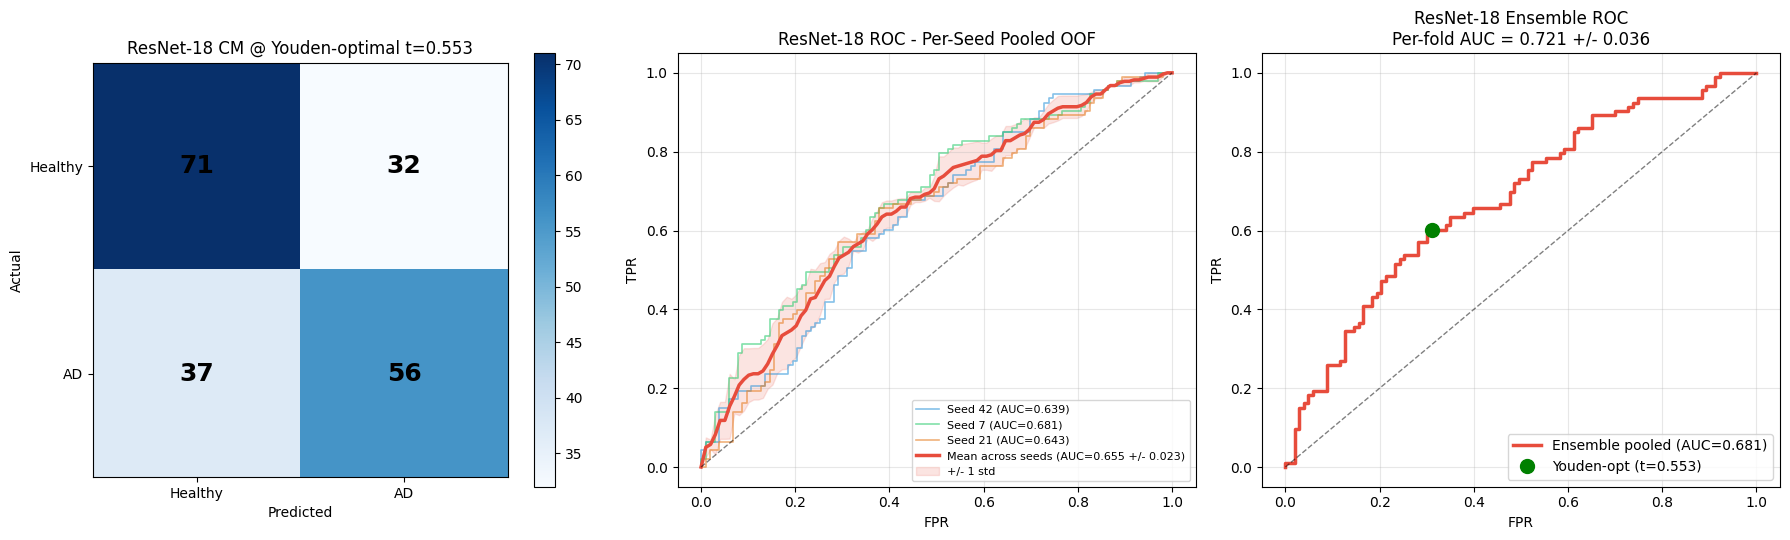

Saved plot: /content/drive/MyDrive/alzheimer_project/results_kfold_v3/resnet18_plots.png


In [ ]:
resnet_report = print_full_results(resnet_results)
plot_architecture_results(resnet_results, resnet_report,
                          save_path=str(RESULTS_DIR / 'resnet18_plots.png'))

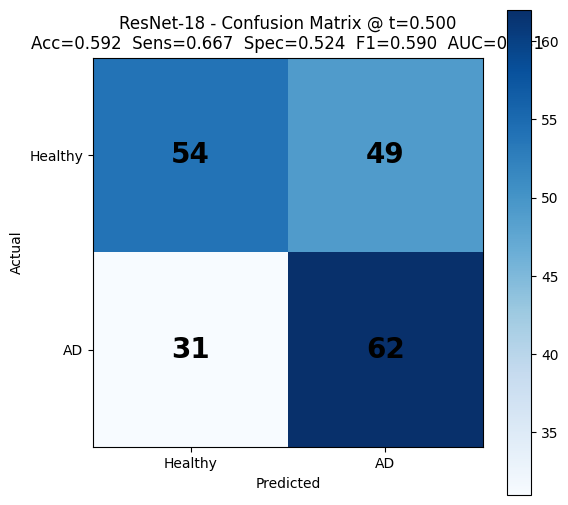


Confusion matrix at t=0.500:
                   Predicted
                   Healthy   AD
   Actual Healthy     54      49
   Actual AD          31      62

Classification report:
              precision    recall  f1-score   support

     Healthy       0.64      0.52      0.57       103
          AD       0.56      0.67      0.61        93

    accuracy                           0.59       196
   macro avg       0.60      0.60      0.59       196
weighted avg       0.60      0.59      0.59       196



In [ ]:
# The Confusion Matrix at 0.5
for t in [0.50]:
    plot_cm_at_threshold(resnet_results, t)

## 10. DenseNet-121: Train

In [ ]:
print(f'Starting DenseNet-121 K-Fold: {N_FOLDS} x {len(ENSEMBLE_SEEDS)} = '
      f'{N_FOLDS * len(ENSEMBLE_SEEDS)} models')
t0 = time.time()
densenet_results = run_kfold_ensemble('DenseNet-121', build_densenet121)
print(f'\nDenseNet-121 done in {(time.time()-t0)/3600:.2f} h')
save_full_results(densenet_results)

Starting DenseNet-121 K-Fold: 5 x 3 = 15 models

  FOLD 1/5
  Split: 117 train, 39 val, 40 test
    Seed  42: best ep 22 (stopped 37), score=+0.438 (val_auc=0.661, val_loss=0.746), test_auc=0.566, time=11.6m
    Seed   7: best ep 37 (stopped 52), score=+0.469 (val_auc=0.680, val_loss=0.704), test_auc=0.539, time=16.3m
    Seed  21: best ep 22 (stopped 37), score=+0.437 (val_auc=0.648, val_loss=0.704), test_auc=0.574, time=11.7m
  Fold 1 ensemble (TTA=True): AUC=0.571

  FOLD 2/5
  Split: 117 train, 40 val, 39 test
    Seed  42: best ep 25 (stopped 40), score=+0.466 (val_auc=0.679, val_loss=0.710), test_auc=0.709, time=12.6m
    Seed   7: best ep 52 (stopped 60), score=+0.498 (val_auc=0.707, val_loss=0.696), test_auc=0.786, time=18.6m
    Seed  21: best ep 20 (stopped 35), score=+0.465 (val_auc=0.664, val_loss=0.662), test_auc=0.675, time=10.9m
  Fold 2 ensemble (TTA=True): AUC=0.738

  FOLD 3/5
  Split: 117 train, 40 val, 39 test
    Seed  42: best ep 31 (stopped 46), score=+0.609 (val

## 11. DenseNet-121: Results & Plots


  DenseNet-121 - 5-FOLD CV x 3-SEED ENSEMBLE (TTA=True)
  196 subjects (each tested exactly once)

  *** PRIMARY METRICS - per-fold mean +/- std (k-fold standard) ***
  *** All metrics @ Youden-optimal threshold = 0.487 (J=0.286) ***
    AUC          = 0.666 +/- 0.063
    Accuracy     = 0.644 +/- 0.089
    Sensitivity  = 0.646 +/- 0.053
    Specificity  = 0.643 +/- 0.160
    F1 (weighted)= 0.642 +/- 0.092

  Per-fold breakdown:


,fold,AUC,Accuracy,Sensitivity,Specificity,F1
0,1,0.571,0.500,0.632,0.381,0.492
1,2,0.738,0.718,0.722,0.714,0.718
2,3,0.646,0.641,0.667,0.619,0.641
3,4,0.676,0.718,0.632,0.800,0.716
4,5,0.697,0.641,0.579,0.700,0.640
5,mean,0.666,0.644,0.646,0.643,0.642
6,std,0.063,0.089,0.053,0.160,0.092



  --- Pooled OOF (concatenated 196 predictions, secondary) ---
    @ Youden t=0.487: AUC=0.663, Acc=0.643, Sens=0.645, Spec=0.641
    @ default  t=0.50: AUC=0.663, Acc=0.628, Sens=0.581, Spec=0.670

  Confusion Matrix @ Youden threshold 0.487 (pooled OOF):
                   Predicted
                   Healthy   AD
   Actual Healthy     66      37
   Actual AD          33      60

  Classification report @ Youden threshold 0.487:
              precision    recall  f1-score   support

     Healthy       0.67      0.64      0.65       103
          AD       0.62      0.65      0.63        93

    accuracy                           0.64       196
   macro avg       0.64      0.64      0.64       196
weighted avg       0.64      0.64      0.64       196

  Threshold comparison (pooled OOF):


,threshold,accuracy,sensitivity,specificity,f1
0,0.35,0.577,0.903,0.282,0.534
1,0.40,0.602,0.871,0.359,0.576
2,0.45,0.602,0.710,0.505,0.599
3,0.50,0.628,0.581,0.670,0.627
4,0.55,0.617,0.419,0.796,0.602
5,0.60,0.597,0.323,0.845,0.566


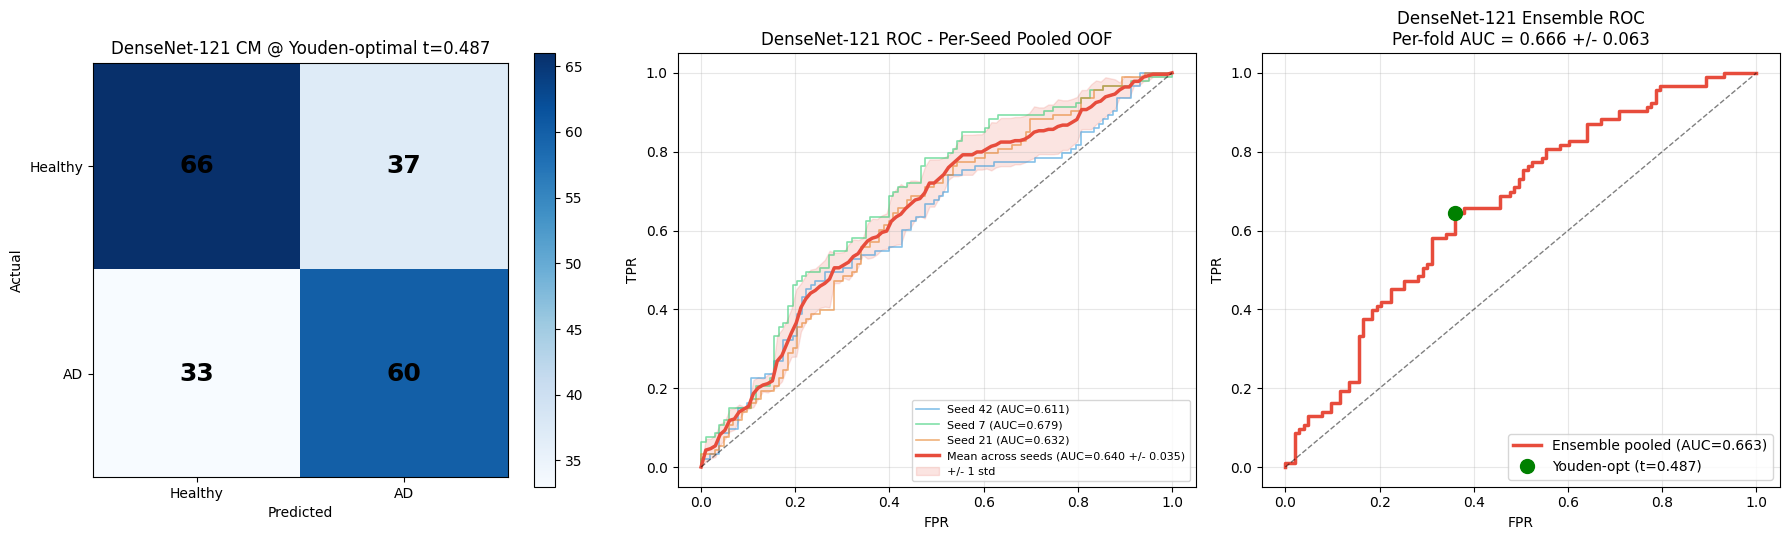

Saved plot: /content/drive/MyDrive/alzheimer_project/results_kfold_v3/densenet121_plots.png


In [ ]:
densenet_report = print_full_results(densenet_results)
plot_architecture_results(densenet_results, densenet_report,
                          save_path=str(RESULTS_DIR / 'densenet121_plots.png'))

In [10]:
def reload_results(model_name, fname):
    """Reload results dict from disk after a session disconnect.
    Works with both 'progress' and 'results' npz files.
    """
    path = RESULTS_DIR / fname
    if not path.exists():
        raise FileNotFoundError(f'{path} not found')
    data = np.load(path)
    return {
        'model_name': model_name,
        'all_test_probs': data['probs'],
        'all_test_labels': data['labels'],
        'per_seed_probs': {s: data[f'per_seed_{s}'] for s in ENSEMBLE_SEEDS},
        # fold_records reconstructed from same StratifiedKFold seed
        'fold_records': [
            {'fold': i + 1, 'test_idx': test_idx.tolist(),
             'ensemble_auc': roc_auc_score(data['labels'][test_idx], data['probs'][test_idx]),
             'per_seed_aucs': {s: roc_auc_score(data['labels'][test_idx], data[f'per_seed_{s}'][test_idx])
                               for s in ENSEMBLE_SEEDS}}
            for i, (_, test_idx) in enumerate(
                StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
                .split(np.zeros(len(data['labels'])), data['labels'])
            )
        ],
    }

# Reload whatever you need:
resnet_results = reload_results('ResNet-18', 'resnet18_results.npz')
densenet_results = reload_results('DenseNet-121', 'densenet121_results.npz')
resnet_report = print_full_results(resnet_results)
densenet_report = print_full_results(densenet_results)
print('Reloaded both. You can now call plot_cm_at_threshold(...) normally.')


  ResNet-18 - 5-FOLD CV x 3-SEED ENSEMBLE (TTA=True)
  196 subjects (each tested exactly once)

  *** PRIMARY METRICS - per-fold mean +/- std (k-fold standard) ***
  *** All metrics @ Youden-optimal threshold = 0.553 (J=0.291) ***
    AUC          = 0.721 +/- 0.036
    Accuracy     = 0.648 +/- 0.065
    Sensitivity  = 0.598 +/- 0.254
    Specificity  = 0.689 +/- 0.129
    F1 (weighted)= 0.633 +/- 0.091

  Per-fold breakdown:


,fold,AUC,Accuracy,Sensitivity,Specificity,F1
0,1,0.719,0.625,0.684,0.571,0.624
1,2,0.669,0.564,0.167,0.905,0.492
2,3,0.738,0.641,0.667,0.619,0.641
3,4,0.711,0.667,0.632,0.700,0.666
4,5,0.766,0.744,0.842,0.650,0.742
5,mean,0.721,0.648,0.598,0.689,0.633
6,std,0.036,0.065,0.254,0.129,0.091



  --- Pooled OOF (concatenated 196 predictions, secondary) ---
    @ Youden t=0.553: AUC=0.681, Acc=0.648, Sens=0.602, Spec=0.689
    @ default  t=0.50: AUC=0.681, Acc=0.592, Sens=0.667, Spec=0.524

  Confusion Matrix @ Youden threshold 0.553 (pooled OOF):
                   Predicted
                   Healthy   AD
   Actual Healthy     71      32
   Actual AD          37      56

  Classification report @ Youden threshold 0.553:
              precision    recall  f1-score   support

     Healthy       0.66      0.69      0.67       103
          AD       0.64      0.60      0.62        93

    accuracy                           0.65       196
   macro avg       0.65      0.65      0.65       196
weighted avg       0.65      0.65      0.65       196

  Threshold comparison (pooled OOF):


,threshold,accuracy,sensitivity,specificity,f1
0,0.35,0.592,0.892,0.320,0.558
1,0.40,0.597,0.828,0.388,0.578
2,0.45,0.612,0.763,0.476,0.605
3,0.50,0.592,0.667,0.524,0.590
4,0.55,0.648,0.602,0.689,0.647
5,0.60,0.633,0.452,0.796,0.621



  DenseNet-121 - 5-FOLD CV x 3-SEED ENSEMBLE (TTA=True)
  196 subjects (each tested exactly once)

  *** PRIMARY METRICS - per-fold mean +/- std (k-fold standard) ***
  *** All metrics @ Youden-optimal threshold = 0.487 (J=0.286) ***
    AUC          = 0.666 +/- 0.063
    Accuracy     = 0.644 +/- 0.089
    Sensitivity  = 0.646 +/- 0.053
    Specificity  = 0.643 +/- 0.160
    F1 (weighted)= 0.642 +/- 0.092

  Per-fold breakdown:


,fold,AUC,Accuracy,Sensitivity,Specificity,F1
0,1,0.571,0.500,0.632,0.381,0.492
1,2,0.738,0.718,0.722,0.714,0.718
2,3,0.646,0.641,0.667,0.619,0.641
3,4,0.676,0.718,0.632,0.800,0.716
4,5,0.697,0.641,0.579,0.700,0.640
5,mean,0.666,0.644,0.646,0.643,0.642
6,std,0.063,0.089,0.053,0.160,0.092



  --- Pooled OOF (concatenated 196 predictions, secondary) ---
    @ Youden t=0.487: AUC=0.663, Acc=0.643, Sens=0.645, Spec=0.641
    @ default  t=0.50: AUC=0.663, Acc=0.628, Sens=0.581, Spec=0.670

  Confusion Matrix @ Youden threshold 0.487 (pooled OOF):
                   Predicted
                   Healthy   AD
   Actual Healthy     66      37
   Actual AD          33      60

  Classification report @ Youden threshold 0.487:
              precision    recall  f1-score   support

     Healthy       0.67      0.64      0.65       103
          AD       0.62      0.65      0.63        93

    accuracy                           0.64       196
   macro avg       0.64      0.64      0.64       196
weighted avg       0.64      0.64      0.64       196

  Threshold comparison (pooled OOF):


,threshold,accuracy,sensitivity,specificity,f1
0,0.35,0.577,0.903,0.282,0.534
1,0.40,0.602,0.871,0.359,0.576
2,0.45,0.602,0.710,0.505,0.599
3,0.50,0.628,0.581,0.670,0.627
4,0.55,0.617,0.419,0.796,0.602
5,0.60,0.597,0.323,0.845,0.566


Reloaded both. You can now call plot_cm_at_threshold(...) normally.


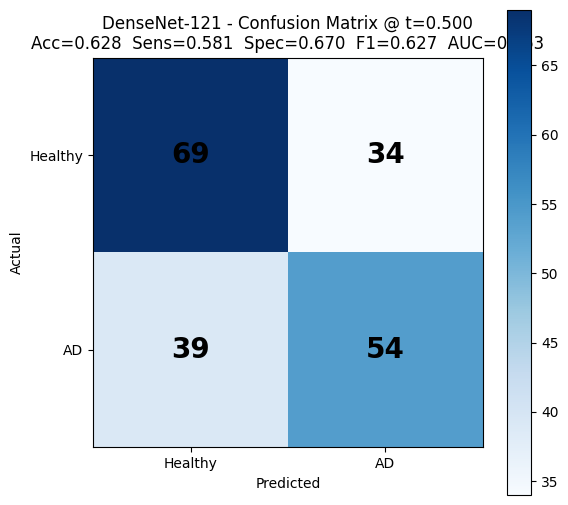


Confusion matrix at t=0.500:
                   Predicted
                   Healthy   AD
   Actual Healthy     69      34
   Actual AD          39      54

Classification report:
              precision    recall  f1-score   support

     Healthy       0.64      0.67      0.65       103
          AD       0.61      0.58      0.60        93

    accuracy                           0.63       196
   macro avg       0.63      0.63      0.63       196
weighted avg       0.63      0.63      0.63       196



In [ ]:
# The Confusion Matrix at 0.5
for t in [ 0.50]:
    plot_cm_at_threshold(densenet_results, t)

# Pretrained ResNet-18 (MedicalNet)

In [11]:
# %% ========================================================================
# CELL: ## 14. Pretrained ResNet-18 (MedicalNet) — Download Weights
# ========================================================================
!pip install -q huggingface_hub
from huggingface_hub import hf_hub_download
import os
PRETRAINED_DIR = DRIVE_DATA_DIR / 'pretrained'
PRETRAINED_DIR.mkdir(exist_ok=True)
PRETRAINED_WEIGHTS = PRETRAINED_DIR / 'resnet_18_23dataset.pth'
if not PRETRAINED_WEIGHTS.exists():
    print('Downloading MedicalNet ResNet-18 pretrained weights from HuggingFace...')
    downloaded = hf_hub_download(
        repo_id='TencentMedicalNet/MedicalNet-Resnet18',
        filename='resnet_18_23dataset.pth',
        local_dir=str(PRETRAINED_DIR),
    )
    print(f'Downloaded to: {downloaded}')
else:
    print(f'Pretrained weights already exist: {PRETRAINED_WEIGHTS}')
print(f'File size: {os.path.getsize(PRETRAINED_WEIGHTS) / 1e6:.1f} MB')

Pretrained weights already exist: /content/drive/MyDrive/alzheimer_project/pretrained/resnet_18_23dataset.pth
File size: 132.0 MB


In [12]:
# %% ========================================================================
# CELL: ## 15. Pretrained Config & Model Builder
# ========================================================================
# ---------- Pretrained-specific config (existing constants unchanged) ----------
PT_PHASE1_EPOCHS = 10         # head-only training
PT_PHASE2_EPOCHS = 40         # fine-tune deeper layers
PT_TOTAL_EPOCHS  = PT_PHASE1_EPOCHS + PT_PHASE2_EPOCHS  # 50 total
PT_WARMUP_BEST   = 5          # within phase 2, wait 5 epochs before checkpointing
PT_MIN_EPOCHS_P2 = 15         # min epochs in phase 2 before early stop allowed
PT_PATIENCE      = 12         # early stopping patience in phase 2
PT_LR_HEAD       = 1e-3       # phase 1: head learning rate
PT_LR_DEEP       = 1e-5       # phase 2: layer3 learning rate
PT_LR_DEEPER     = 5e-5       # phase 2: layer4 learning rate
PT_LR_HEAD_P2    = 1e-4       # phase 2: head learning rate (reduced)
PT_DROPOUT       = 0.5        # same as original ResNet
PT_LABEL         = 'ResNet-18-PT'  # label for results
print('Pretrained config:')
print(f'  Phase 1: {PT_PHASE1_EPOCHS} epochs (head only, lr={PT_LR_HEAD})')
print(f'  Phase 2: up to {PT_PHASE2_EPOCHS} epochs (layer3/4/fc, '
      f'lr={PT_LR_DEEP}/{PT_LR_DEEPER}/{PT_LR_HEAD_P2})')
print(f'  Patience: {PT_PATIENCE}, min phase2 epochs: {PT_MIN_EPOCHS_P2}')
def build_resnet18_pretrained(seed=RANDOM_SEED):
    """Build ResNet-18 with MedicalNet pretrained backbone. Returns model on device."""
    seed_everything(seed)
    # 1. Build fresh MONAI ResNet-18 (same architecture as original)
    model = resnet18(spatial_dims=3, n_input_channels=1, num_classes=NUM_CLASSES)
    # 2. Load MedicalNet pretrained weights
    checkpoint = torch.load(PRETRAINED_WEIGHTS, map_location='cpu', weights_only=False)
    pretrained_dict = checkpoint.get('state_dict', checkpoint)
    # Strip 'module.' prefix (from DataParallel training)
    pretrained_dict = {k.replace('module.', ''): v for k, v in pretrained_dict.items()}
    # Match only keys that exist in our model AND have same shape
    model_dict = model.state_dict()
    matched = {}
    skipped_shape = []
    skipped_missing = []
    for k, v in pretrained_dict.items():
        if k in model_dict:
            if v.shape == model_dict[k].shape:
                matched[k] = v
            else:
                skipped_shape.append(f'  {k}: pretrained={list(v.shape)} vs model={list(model_dict[k].shape)}')
        else:
            skipped_missing.append(k)
    model_dict.update(matched)
    model.load_state_dict(model_dict)
    print(f'  MedicalNet: loaded {len(matched)}/{len(model_dict)} layers')
    if skipped_shape:
        print(f'  Shape mismatches ({len(skipped_shape)}):')
        for s in skipped_shape:
            print(s)
    if skipped_missing:
        print(f'  Keys only in pretrained (skipped): {len(skipped_missing)}')
    # 3. Replace FC head (same as original notebook)
    model.fc = nn.Sequential(nn.Dropout(PT_DROPOUT), nn.Linear(512, NUM_CLASSES))
    return model.to(device)
# Quick test: build and check
_test_model = build_resnet18_pretrained(42)
del _test_model
torch.cuda.empty_cache()
print('\nPretrained model builder verified ✓')


Pretrained config:
  Phase 1: 10 epochs (head only, lr=0.001)
  Phase 2: up to 40 epochs (layer3/4/fc, lr=1e-05/5e-05/0.0001)
  Patience: 12, min phase2 epochs: 15
  MedicalNet: loaded 102/125 layers

Pretrained model builder verified ✓


In [13]:
# %% ========================================================================
# CELL: ## 16. Two-Phase K-Fold Training Engine
# ========================================================================
def run_kfold_pretrained():
    """
    5-Fold CV x 3-Seed ensemble with TWO-PHASE fine-tuning.
    Phase 1: freeze backbone, train only FC head.
    Phase 2: unfreeze layer3+layer4, discriminative LR, early stopping.
    Uses ALL existing helpers (evaluate, train_one_epoch, etc.) unchanged.
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    save_dir = CHECKPOINT_DIR / 'resnet18_pt'
    save_dir.mkdir(exist_ok=True)
    n = len(all_data)
    all_test_probs  = np.zeros(n)
    all_test_labels = np.zeros(n, dtype=int)
    per_seed_probs  = {s: np.zeros(n) for s in ENSEMBLE_SEEDS}
    fold_records    = []
    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(np.zeros(n), all_labels)):
        print(f'\n{"="*70}\n  FOLD {fold_idx+1}/{N_FOLDS}\n{"="*70}')
        # Same train/val split as original
        trainval_lbls = all_labels[trainval_idx]
        sub_train, sub_val = train_test_split(
            np.arange(len(trainval_idx)), test_size=VAL_FRACTION,
            stratify=trainval_lbls, random_state=RANDOM_SEED,
        )
        train_idx = trainval_idx[sub_train]
        val_idx   = trainval_idx[sub_val]
        print(f'  Split: {len(train_idx)} train, {len(val_idx)} val, {len(test_idx)} test')
        # Class weights from training fold
        cls_counts = np.bincount(all_labels[train_idx]).astype(np.float32)
        cls_w = 1.0 / cls_counts
        cls_w = cls_w / cls_w.sum() * len(cls_counts)
        weights_tensor = torch.FloatTensor(cls_w).to(device)
        # Datasets & loaders (reuse existing classes)
        train_ds = AugmentedSubset(full_ds, train_idx, aug=train_aug)
        val_ds   = AugmentedSubset(full_ds, val_idx,   aug=None)
        test_ds  = AugmentedSubset(full_ds, test_idx,  aug=None)
        val_loader  = make_loader(val_ds,  shuffle=False)
        test_loader = make_loader(test_ds, shuffle=False)
        fold_seed_probs  = []
        fold_test_labels = None
        per_seed_aucs    = {}
        for seed in ENSEMBLE_SEEDS:
            seed_everything(seed)
            model = build_resnet18_pretrained(seed)
            criterion = nn.CrossEntropyLoss(weight=weights_tensor,
                                            label_smoothing=LABEL_SMOOTHING)
            train_loader = make_loader(train_ds, shuffle=True, seed=seed)
            # ====== PHASE 1: Head only ======
            # Freeze entire backbone
            for name, param in model.named_parameters():
                if 'fc' not in name:
                    param.requires_grad = False
            opt_p1 = torch.optim.Adam(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=PT_LR_HEAD, weight_decay=WEIGHT_DECAY,
            )
            t_seed = time.time()
            for ep in range(1, PT_PHASE1_EPOCHS + 1):
                train_one_epoch(model, train_loader, criterion, opt_p1, device)
            val_loss_p1, val_auc_p1, _, _ = evaluate(model, val_loader, criterion, device, tta=False)
            print(f'    Seed {seed:>3d} Phase1 done ({PT_PHASE1_EPOCHS}ep): '
                  f'val_auc={val_auc_p1:.3f}, val_loss={val_loss_p1:.3f}')
            # ====== PHASE 2: Unfreeze deep layers ======
            # Unfreeze layer3 + layer4 (layer1 & layer2 stay frozen)
            for name, param in model.named_parameters():
                if any(x in name for x in ['layer3', 'layer4', 'fc']):
                    param.requires_grad = True
            opt_p2 = torch.optim.Adam([
                {'params': [p for n, p in model.named_parameters() if 'layer3' in n and p.requires_grad],
                 'lr': PT_LR_DEEP},
                {'params': [p for n, p in model.named_parameters() if 'layer4' in n and p.requires_grad],
                 'lr': PT_LR_DEEPER},
                {'params': model.fc.parameters(),
                 'lr': PT_LR_HEAD_P2},
            ], weight_decay=WEIGHT_DECAY)
            sched_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
                opt_p2, T_max=PT_PHASE2_EPOCHS, eta_min=1e-7,
            )
            best_score = -float('inf')
            best_val_auc = 0.0
            best_val_loss = float('inf')
            best_state = None
            best_epoch = 0
            patience_counter = 0
            for ep in range(1, PT_PHASE2_EPOCHS + 1):
                train_one_epoch(model, train_loader, criterion, opt_p2, device)
                val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, device, tta=False)
                sched_p2.step()
                score = val_auc - COMPOSITE_LOSS_WEIGHT * val_loss
                if ep >= PT_WARMUP_BEST:
                    if score > best_score:
                        best_score = score
                        best_val_auc = val_auc
                        best_val_loss = val_loss
                        best_state = {k: v.detach().cpu().clone()
                                      for k, v in model.state_dict().items()}
                        best_epoch = PT_PHASE1_EPOCHS + ep
                        patience_counter = 0
                    else:
                        patience_counter += 1
                if ep >= PT_MIN_EPOCHS_P2 and patience_counter >= PT_PATIENCE:
                    break
            total_ep = PT_PHASE1_EPOCHS + ep
            # Load best checkpoint
            if best_state is not None:
                model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
            torch.save(model.state_dict(), save_dir / f'fold{fold_idx+1}_seed{seed}.pth')
            # Test with TTA
            _, _, t_lbls, t_probs = evaluate(model, test_loader, criterion, device, tta=USE_TTA)
            fold_seed_probs.append(t_probs)
            fold_test_labels = t_lbls
            per_seed_probs[seed][test_idx] = t_probs
            seed_test_auc = roc_auc_score(t_lbls, t_probs)
            per_seed_aucs[seed] = seed_test_auc
            print(f'    Seed {seed:>3d}: best ep {best_epoch:>2d} (stopped {total_ep:>2d}), '
                  f'score={best_score:+.3f} (val_auc={best_val_auc:.3f}, '
                  f'val_loss={best_val_loss:.3f}), '
                  f'test_auc={seed_test_auc:.3f}, time={(time.time()-t_seed)/60:.1f}m')
            del model, opt_p1, opt_p2, sched_p2, best_state
            torch.cuda.empty_cache()
        # Ensemble across seeds
        fold_ens_probs = np.mean(np.stack(fold_seed_probs), axis=0)
        all_test_probs[test_idx]  = fold_ens_probs
        all_test_labels[test_idx] = fold_test_labels
        ens_auc = roc_auc_score(fold_test_labels, fold_ens_probs)
        fold_records.append({
            'fold': fold_idx + 1,
            'test_idx': test_idx.tolist(),
            'ensemble_auc': ens_auc,
            'per_seed_aucs': per_seed_aucs,
        })
        print(f'  Fold {fold_idx+1} ensemble (TTA={USE_TTA}): AUC={ens_auc:.3f}')
        # Incremental save
        np.savez(
            RESULTS_DIR / f'resnet18_pt_progress.npz',
            probs=all_test_probs, labels=all_test_labels,
            completed_folds=fold_idx + 1,
            **{f'per_seed_{s_}': per_seed_probs[s_] for s_ in ENSEMBLE_SEEDS},
        )
    results = {
        'model_name': PT_LABEL,
        'all_test_probs':  all_test_probs,
        'all_test_labels': all_test_labels,
        'per_seed_probs':  per_seed_probs,
        'fold_records':    fold_records,
        'weight_dir':      str(save_dir),
    }
    # Save final
    np.savez(
        RESULTS_DIR / 'resnet18_pt_results.npz',
        probs=all_test_probs, labels=all_test_labels,
        **{f'per_seed_{s}': per_seed_probs[s] for s in ENSEMBLE_SEEDS},
    )
    print(f'\nSaved resnet18_pt_results.npz to {RESULTS_DIR}')
    return results
print('Two-phase training engine ready')
print(f'  Will train {N_FOLDS} folds x {len(ENSEMBLE_SEEDS)} seeds = '
      f'{N_FOLDS * len(ENSEMBLE_SEEDS)} models')
print(f'  Each model: {PT_PHASE1_EPOCHS} (head) + up to {PT_PHASE2_EPOCHS} (fine-tune) epochs')


Two-phase training engine ready
  Will train 5 folds x 3 seeds = 15 models
  Each model: 10 (head) + up to 40 (fine-tune) epochs


In [ ]:
# %% ========================================================================
# CELL: ## 17. Train Pretrained ResNet-18
# ========================================================================
print(f'Starting Pretrained ResNet-18: {N_FOLDS} folds x {len(ENSEMBLE_SEEDS)} seeds')
t0 = time.time()
resnet_pt_results = run_kfold_pretrained()
print(f'\nPretrained ResNet-18 done in {(time.time()-t0)/3600:.2f} h')


Starting Pretrained ResNet-18: 5 folds x 3 seeds

  FOLD 1/5
  Split: 117 train, 39 val, 40 test
  MedicalNet: loaded 102/125 layers
    Seed  42 Phase1 done (10ep): val_auc=0.463, val_loss=0.710
    Seed  42: best ep 25 (stopped 37), score=+0.476 (val_auc=0.685, val_loss=0.699), test_auc=0.609, time=11.0m
  MedicalNet: loaded 102/125 layers
    Seed   7 Phase1 done (10ep): val_auc=0.479, val_loss=0.697
    Seed   7: best ep 16 (stopped 28), score=+0.524 (val_auc=0.714, val_loss=0.634), test_auc=0.589, time=8.1m
  MedicalNet: loaded 102/125 layers
    Seed  21 Phase1 done (10ep): val_auc=0.489, val_loss=0.712
    Seed  21: best ep 18 (stopped 30), score=+0.508 (val_auc=0.712, val_loss=0.679), test_auc=0.506, time=8.8m
  Fold 1 ensemble (TTA=True): AUC=0.581

  FOLD 2/5
  Split: 117 train, 40 val, 39 test
  MedicalNet: loaded 102/125 layers
    Seed  42 Phase1 done (10ep): val_auc=0.576, val_loss=1.032
    Seed  42: best ep 28 (stopped 40), score=+0.437 (val_auc=0.649, val_loss=0.708), 


  ResNet-18-PT - 5-FOLD CV x 3-SEED ENSEMBLE (TTA=True)
  196 subjects (each tested exactly once)

  *** PRIMARY METRICS - per-fold mean +/- std (k-fold standard) ***
  *** All metrics @ Youden-optimal threshold = 0.587 (J=0.331) ***
    AUC          = 0.688 +/- 0.091
    Accuracy     = 0.669 +/- 0.054
    Sensitivity  = 0.613 +/- 0.130
    Specificity  = 0.719 +/- 0.095
    F1 (weighted)= 0.665 +/- 0.057

  Per-fold breakdown:


,fold,AUC,Accuracy,Sensitivity,Specificity,F1
0,1,0.581,0.600,0.421,0.762,0.588
1,2,0.653,0.641,0.556,0.714,0.639
2,3,0.693,0.692,0.722,0.667,0.693
3,4,0.682,0.667,0.737,0.600,0.665
4,5,0.832,0.744,0.632,0.850,0.740
5,mean,0.688,0.669,0.613,0.719,0.665
6,std,0.091,0.054,0.130,0.095,0.057



  --- Pooled OOF (concatenated 196 predictions, secondary) ---
    @ Youden t=0.587: AUC=0.674, Acc=0.668, Sens=0.613, Spec=0.718
    @ default  t=0.50: AUC=0.674, Acc=0.628, Sens=0.753, Spec=0.515

  Confusion Matrix @ Youden threshold 0.587 (pooled OOF):
                   Predicted
                   Healthy   AD
   Actual Healthy     74      29
   Actual AD          36      57

  Classification report @ Youden threshold 0.587:
              precision    recall  f1-score   support

     Healthy       0.67      0.72      0.69       103
          AD       0.66      0.61      0.64        93

    accuracy                           0.67       196
   macro avg       0.67      0.67      0.67       196
weighted avg       0.67      0.67      0.67       196

  Threshold comparison (pooled OOF):


,threshold,accuracy,sensitivity,specificity,f1
0,0.35,0.597,0.914,0.311,0.559
1,0.40,0.622,0.892,0.379,0.598
2,0.45,0.617,0.828,0.427,0.603
3,0.50,0.628,0.753,0.515,0.623
4,0.55,0.628,0.667,0.592,0.627
5,0.60,0.648,0.559,0.728,0.645


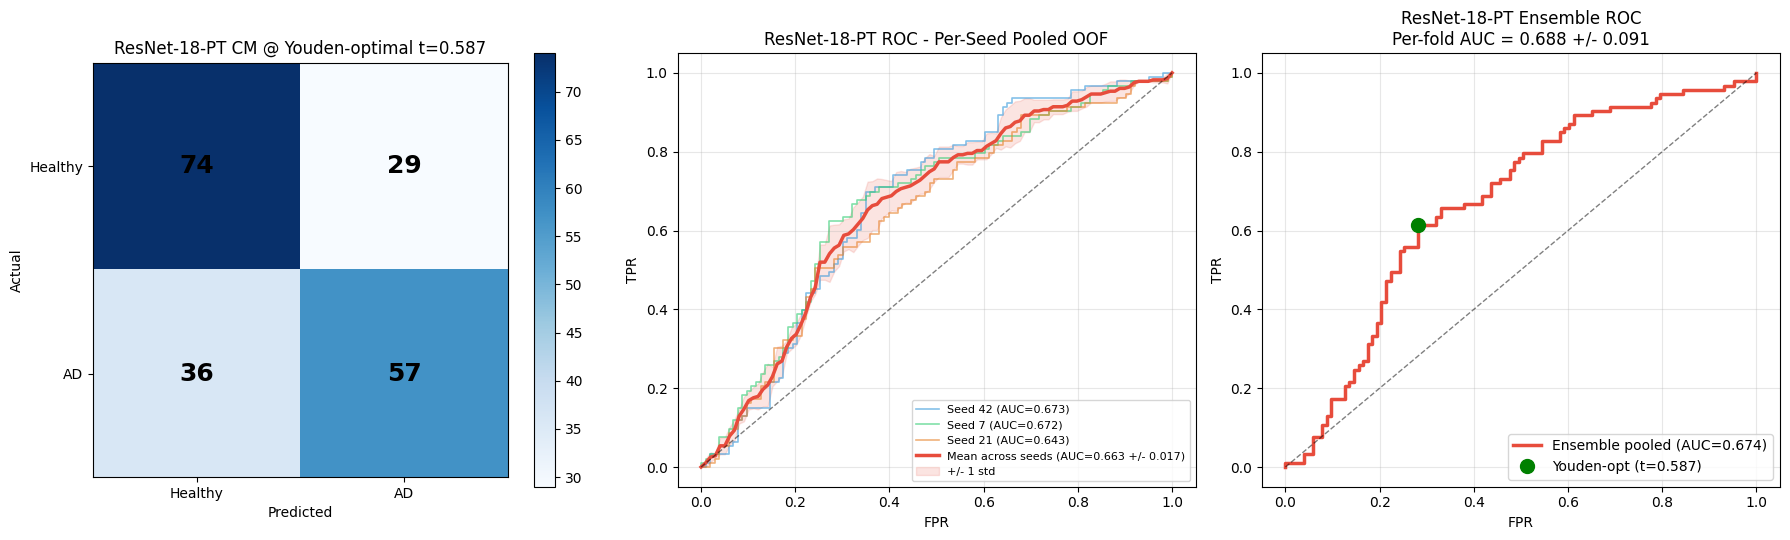

Saved plot: /content/drive/MyDrive/alzheimer_project/results_kfold_v3/resnet18_pt_plots.png


In [ ]:
# %% ========================================================================
# CELL: ## 18. Pretrained ResNet-18: Results & Plots
# ========================================================================
resnet_pt_report = print_full_results(resnet_pt_results)
plot_architecture_results(resnet_pt_results, resnet_pt_report,
                          save_path=str(RESULTS_DIR / 'resnet18_pt_plots.png'))


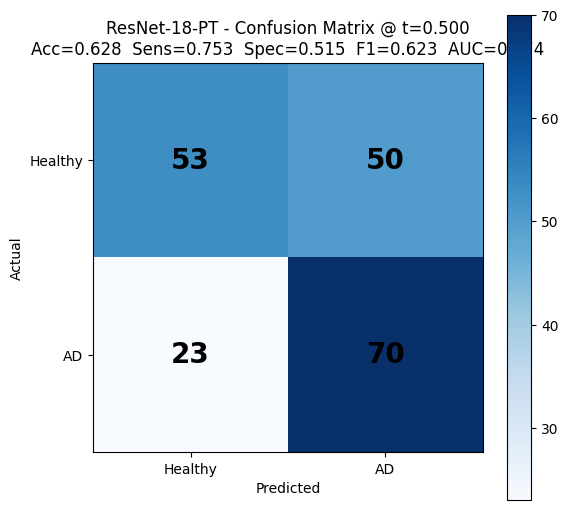


Confusion matrix at t=0.500:
                   Predicted
                   Healthy   AD
   Actual Healthy     53      50
   Actual AD          23      70

Classification report:
              precision    recall  f1-score   support

     Healthy       0.70      0.51      0.59       103
          AD       0.58      0.75      0.66        93

    accuracy                           0.63       196
   macro avg       0.64      0.63      0.62       196
weighted avg       0.64      0.63      0.62       196



In [ ]:
# The Confusion Matrix at 0.5
for t in [0.5]:
    plot_cm_at_threshold(resnet_pt_results, t)



  ResNet-18-PT - 5-FOLD CV x 3-SEED ENSEMBLE (TTA=True)
  196 subjects (each tested exactly once)

  *** PRIMARY METRICS - per-fold mean +/- std (k-fold standard) ***
  *** All metrics @ Youden-optimal threshold = 0.587 (J=0.331) ***
    AUC          = 0.688 +/- 0.091
    Accuracy     = 0.669 +/- 0.054
    Sensitivity  = 0.613 +/- 0.130
    Specificity  = 0.719 +/- 0.095
    F1 (weighted)= 0.665 +/- 0.057

  Per-fold breakdown:


,fold,AUC,Accuracy,Sensitivity,Specificity,F1
0,1,0.581,0.600,0.421,0.762,0.588
1,2,0.653,0.641,0.556,0.714,0.639
2,3,0.693,0.692,0.722,0.667,0.693
3,4,0.682,0.667,0.737,0.600,0.665
4,5,0.832,0.744,0.632,0.850,0.740
5,mean,0.688,0.669,0.613,0.719,0.665
6,std,0.091,0.054,0.130,0.095,0.057



  --- Pooled OOF (concatenated 196 predictions, secondary) ---
    @ Youden t=0.587: AUC=0.674, Acc=0.668, Sens=0.613, Spec=0.718
    @ default  t=0.50: AUC=0.674, Acc=0.628, Sens=0.753, Spec=0.515

  Confusion Matrix @ Youden threshold 0.587 (pooled OOF):
                   Predicted
                   Healthy   AD
   Actual Healthy     74      29
   Actual AD          36      57

  Classification report @ Youden threshold 0.587:
              precision    recall  f1-score   support

     Healthy       0.67      0.72      0.69       103
          AD       0.66      0.61      0.64        93

    accuracy                           0.67       196
   macro avg       0.67      0.67      0.67       196
weighted avg       0.67      0.67      0.67       196

  Threshold comparison (pooled OOF):


,threshold,accuracy,sensitivity,specificity,f1
0,0.35,0.597,0.914,0.311,0.559
1,0.40,0.622,0.892,0.379,0.598
2,0.45,0.617,0.828,0.427,0.603
3,0.50,0.628,0.753,0.515,0.623
4,0.55,0.628,0.667,0.592,0.627
5,0.60,0.648,0.559,0.728,0.645


  FROM-SCRATCH vs PRETRAINED (5-Fold CV x 3-Seed)
  196 subjects, TTA=True


,Model,Youden_t,AUC,Acc,Sens,Spec,F1
0,ResNet-18 (From scratch),0.553146,0.721 ± 0.036,0.648 ± 0.065,0.598 ± 0.254,0.689 ± 0.129,0.633 ± 0.091
1,ResNet-18-PT (MedicalNet pretrained),0.586634,0.688 ± 0.091,0.669 ± 0.054,0.613 ± 0.130,0.719 ± 0.095,0.665 ± 0.057


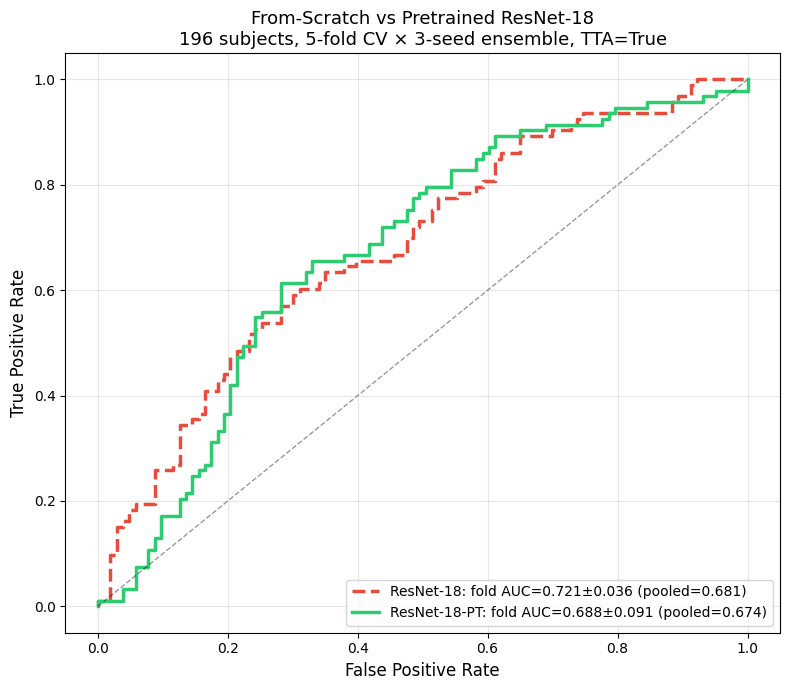

Saved: /content/drive/MyDrive/alzheimer_project/results_kfold_v3/scratch_vs_pretrained_roc.png

  SCREENING THRESHOLD (t=0.40) COMPARISON
  ResNet-18                : Sens=0.828  Spec=0.388  Acc=0.597  AUC=0.681  F1=0.578
  ResNet-18-PT             : Sens=0.892  Spec=0.379  Acc=0.622  AUC=0.674  F1=0.598


In [ ]:
# %% ========================================================================
# CELL: ## 20. Head-to-Head Comparison: From-Scratch vs Pretrained
# ========================================================================
# Reload from-scratch results if needed (uncomment if not in memory):
# resnet_results = reload_results('ResNet-18', 'resnet18_results.npz')
# resnet_report  = print_full_results(resnet_results)
# Reload pretrained results if needed (uncomment if not in memory):
resnet_pt_results = reload_results(PT_LABEL, 'resnet18_pt_results.npz')
resnet_pt_report  = print_full_results(resnet_pt_results)
# ---- Comparison table ----
comp_rows = []
for r, rep, desc in [
    (resnet_results, resnet_report, 'From scratch'),
    (resnet_pt_results, resnet_pt_report, 'MedicalNet pretrained'),
]:
    ft = rep['fold_table']
    mean = ft.loc[ft['fold'] == 'mean'].iloc[0]
    std  = ft.loc[ft['fold'] == 'std'].iloc[0]
    comp_rows.append({
        'Model': f"{r['model_name']} ({desc})",
        'Youden_t': rep['yj_threshold'],
        'AUC':   f"{mean['AUC']:.3f} ± {std['AUC']:.3f}",
        'Acc':   f"{mean['Accuracy']:.3f} ± {std['Accuracy']:.3f}",
        'Sens':  f"{mean['Sensitivity']:.3f} ± {std['Sensitivity']:.3f}",
        'Spec':  f"{mean['Specificity']:.3f} ± {std['Specificity']:.3f}",
        'F1':    f"{mean['F1']:.3f} ± {std['F1']:.3f}",
    })
comp_df = pd.DataFrame(comp_rows)
print('=' * 76)
print(f'  FROM-SCRATCH vs PRETRAINED ({N_FOLDS}-Fold CV x {len(ENSEMBLE_SEEDS)}-Seed)')
print(f'  {len(resnet_results["all_test_labels"])} subjects, TTA={USE_TTA}')
print('=' * 76)
display(comp_df)
# ---- Side-by-side ROC ----
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
for r, rep, color, ls in [
    (resnet_results,    resnet_report,    '#e74c3c', '--'),
    (resnet_pt_results, resnet_pt_report, '#2ecc71', '-'),
]:
    fpr, tpr, _ = roc_curve(r['all_test_labels'], r['all_test_probs'])
    pooled_auc = roc_auc_score(r['all_test_labels'], r['all_test_probs'])
    auc_m, auc_s = rep['auc_mean_std']
    ax.plot(fpr, tpr, color=color, lw=2.5, ls=ls,
            label=f'{r["model_name"]}: fold AUC={auc_m:.3f}±{auc_s:.3f} (pooled={pooled_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('From-Scratch vs Pretrained ResNet-18\n'
             f'{len(resnet_results["all_test_labels"])} subjects, '
             f'{N_FOLDS}-fold CV × {len(ENSEMBLE_SEEDS)}-seed ensemble, TTA={USE_TTA}',
             fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'scratch_vs_pretrained_roc.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR / "scratch_vs_pretrained_roc.png"}')
# ---- Screening threshold comparison (t=0.40) ----
print('\n' + '='*76)
print('  SCREENING THRESHOLD (t=0.40) COMPARISON')
print('='*76)
for r in [resnet_results, resnet_pt_results]:
    s = summarize_predictions(r['all_test_labels'], r['all_test_probs'], 0.4)
    print(f'  {r["model_name"]:25s}: Sens={s["sensitivity"]:.3f}  '
          f'Spec={s["specificity"]:.3f}  Acc={s["accuracy"]:.3f}  '
          f'AUC={s["auc"]:.3f}  F1={s["f1"]:.3f}')



In [14]:
# %% ========================================================================
# CELL: ## 21. (Recovery) Reload Pretrained Results After Disconnect
# ========================================================================
resnet_pt_results = reload_results(PT_LABEL, 'resnet18_pt_results.npz')
resnet_pt_report  = print_full_results(resnet_pt_results)
print('Pretrained results reloaded.')


  ResNet-18-PT - 5-FOLD CV x 3-SEED ENSEMBLE (TTA=True)
  196 subjects (each tested exactly once)

  *** PRIMARY METRICS - per-fold mean +/- std (k-fold standard) ***
  *** All metrics @ Youden-optimal threshold = 0.587 (J=0.331) ***
    AUC          = 0.688 +/- 0.091
    Accuracy     = 0.669 +/- 0.054
    Sensitivity  = 0.613 +/- 0.130
    Specificity  = 0.719 +/- 0.095
    F1 (weighted)= 0.665 +/- 0.057

  Per-fold breakdown:


,fold,AUC,Accuracy,Sensitivity,Specificity,F1
0,1,0.581,0.600,0.421,0.762,0.588
1,2,0.653,0.641,0.556,0.714,0.639
2,3,0.693,0.692,0.722,0.667,0.693
3,4,0.682,0.667,0.737,0.600,0.665
4,5,0.832,0.744,0.632,0.850,0.740
5,mean,0.688,0.669,0.613,0.719,0.665
6,std,0.091,0.054,0.130,0.095,0.057



  --- Pooled OOF (concatenated 196 predictions, secondary) ---
    @ Youden t=0.587: AUC=0.674, Acc=0.668, Sens=0.613, Spec=0.718
    @ default  t=0.50: AUC=0.674, Acc=0.628, Sens=0.753, Spec=0.515

  Confusion Matrix @ Youden threshold 0.587 (pooled OOF):
                   Predicted
                   Healthy   AD
   Actual Healthy     74      29
   Actual AD          36      57

  Classification report @ Youden threshold 0.587:
              precision    recall  f1-score   support

     Healthy       0.67      0.72      0.69       103
          AD       0.66      0.61      0.64        93

    accuracy                           0.67       196
   macro avg       0.67      0.67      0.67       196
weighted avg       0.67      0.67      0.67       196

  Threshold comparison (pooled OOF):


,threshold,accuracy,sensitivity,specificity,f1
0,0.35,0.597,0.914,0.311,0.559
1,0.40,0.622,0.892,0.379,0.598
2,0.45,0.617,0.828,0.427,0.603
3,0.50,0.628,0.753,0.515,0.623
4,0.55,0.628,0.667,0.592,0.627
5,0.60,0.648,0.559,0.728,0.645


Pretrained results reloaded.


In [15]:
# %% ========================================================================
# CELL: ## Random Forest — Feature Extraction & Setup
# ========================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
# ---- Identify available tabular features from the OASIS Excel ----
# CDR is the label (not a feature). Everything else is fair game.
print('Available columns in df:', list(df.columns))
print(f'Subjects: {len(df)}, Labels match all_labels: {(df["label"].values == all_labels).all()}')
# Candidate features (standard OASIS-1 cross-sectional columns)
CANDIDATE_FEATURES = ['Age', 'M/F', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
FEATURE_COLS = [c for c in CANDIDATE_FEATURES if c in df.columns]
print(f'\nUsing features: {FEATURE_COLS}')
# Show per-feature stats and missing values
feat_info = df[FEATURE_COLS].describe().T
feat_info['missing'] = df[FEATURE_COLS].isnull().sum()
display(feat_info[['count', 'missing', 'mean', 'std', 'min', 'max']])
# ---- Prepare feature matrix ----
df_feat = df[FEATURE_COLS].copy()
# Encode M/F as numeric (if present)
if 'M/F' in df_feat.columns:
    df_feat['M/F'] = LabelEncoder().fit_transform(df_feat['M/F'].astype(str))
X = df_feat.values.astype(np.float32)
y = all_labels.copy()
print(f'\nFeature matrix: {X.shape}')
print(f'Labels: {len(y)} (Healthy={sum(y==0)}, AD={sum(y==1)})')

Available columns in df: ['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay', 'mgz_path', 'has_file', 'label']
Subjects: 196, Labels match all_labels: True

Using features: ['Age', 'M/F', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']


,count,missing,mean,std,min,max
Age,196.0,0,75.556122,8.696708,58.000,96.000
Educ,196.0,0,3.040816,1.312022,1.000,5.000
SES,178.0,18,2.606742,1.116066,1.000,5.000
MMSE,196.0,0,26.862245,3.702584,14.000,30.000
eTIV,196.0,0,1461.867347,160.896535,1123.000,1992.000
nWBV,196.0,0,0.740250,0.043144,0.644,0.839
ASF,196.0,0,1.214495,0.128663,0.881,1.563



Feature matrix: (196, 8)
Labels: 196 (Healthy=103, AD=93)


In [16]:
# %% ========================================================================
# CELL: ## Random Forest (MRI + Demographics) — 5-Fold CV × Multi-Seed Ensemble
# ========================================================================
# Uses Age, Sex + MRI-derived features (eTIV, nWBV, ASF)
# — matches the multi-modal CNN's feature set for FAIR comparison.
# Same fold split as the CNN models.

RF_DEMO_COLS = ['Age', 'M/F', 'eTIV', 'nWBV', 'ASF']
df_rfd = df[RF_DEMO_COLS].copy()
df_rfd['M/F'] = LabelEncoder().fit_transform(df_rfd['M/F'].astype(str))
X_rfd = df_rfd.values.astype(np.float32)

skf_rf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# RF hyperparameters (regularized for small dataset)
RF_PARAMS = {
    'n_estimators': 300,
    'max_depth': 6,
    'min_samples_leaf': 5,
    'min_samples_split': 10,
    'class_weight': 'balanced',    # same idea as weighted CE in CNNs
    'max_features': 'sqrt',
    'n_jobs': -1,
}

n = len(y)
rfd_probs       = np.zeros(n)
rfd_all_labels  = np.zeros(n, dtype=int)
rfd_per_seed    = {s: np.zeros(n) for s in ENSEMBLE_SEEDS}
rfd_fold_records = []

print(f'Random Forest (MRI+demo): {N_FOLDS} folds × {len(ENSEMBLE_SEEDS)} seeds = '
      f'{N_FOLDS * len(ENSEMBLE_SEEDS)} models')
print(f'Features: {RF_DEMO_COLS}')
print(f'Params: {RF_PARAMS}\n')

t0 = time.time()
for fold_idx, (trainval_idx, test_idx) in enumerate(skf_rf.split(np.zeros(n), y)):
    # Same train/val split as CNN (val unused by RF, kept for parity)
    trainval_lbls = y[trainval_idx]
    sub_train, sub_val = train_test_split(
        np.arange(len(trainval_idx)), test_size=VAL_FRACTION,
        stratify=trainval_lbls, random_state=RANDOM_SEED,
    )
    train_idx = trainval_idx[sub_train]

    # Impute + scale (fit on train only to avoid leakage)
    imputer = SimpleImputer(strategy='median')
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(imputer.fit_transform(X_rfd[train_idx]))
    X_test  = scaler.transform(imputer.transform(X_rfd[test_idx]))

    fold_seed_probs = []
    per_seed_aucs = {}
    for seed in ENSEMBLE_SEEDS:
        rf = RandomForestClassifier(random_state=seed, **RF_PARAMS)
        rf.fit(X_train, y[train_idx])
        probs = rf.predict_proba(X_test)[:, 1]
        fold_seed_probs.append(probs)
        rfd_per_seed[seed][test_idx] = probs
        per_seed_aucs[seed] = roc_auc_score(y[test_idx], probs)

    # Ensemble: average probabilities across seeds
    ens_probs = np.mean(np.stack(fold_seed_probs), axis=0)
    rfd_probs[test_idx]      = ens_probs
    rfd_all_labels[test_idx] = y[test_idx]
    ens_auc = roc_auc_score(y[test_idx], ens_probs)

    rfd_fold_records.append({
        'fold': fold_idx + 1,
        'test_idx': test_idx.tolist(),
        'ensemble_auc': ens_auc,
        'per_seed_aucs': per_seed_aucs,
    })
    print(f'  Fold {fold_idx+1}: AUC={ens_auc:.3f}  '
          f'(seeds: {", ".join(f"{v:.3f}" for v in per_seed_aucs.values())})')

rf_demo_results = {
    'model_name':      'RF (MRI+demo)',
    'all_test_probs':  rfd_probs,
    'all_test_labels': rfd_all_labels,
    'per_seed_probs':  rfd_per_seed,
    'fold_records':    rfd_fold_records,
    'weight_dir':      'N/A',
}
print(f'\nRandom Forest (MRI+demo) done in {time.time()-t0:.1f}s')

Random Forest (MRI+demo): 5 folds × 3 seeds = 15 models
Features: ['Age', 'M/F', 'eTIV', 'nWBV', 'ASF']
Params: {'n_estimators': 300, 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 10, 'class_weight': 'balanced', 'max_features': 'sqrt', 'n_jobs': -1}

  Fold 1: AUC=0.519  (seeds: 0.514, 0.514, 0.519)
  Fold 2: AUC=0.698  (seeds: 0.685, 0.693, 0.696)
  Fold 3: AUC=0.730  (seeds: 0.725, 0.741, 0.730)
  Fold 4: AUC=0.750  (seeds: 0.732, 0.747, 0.758)
  Fold 5: AUC=0.853  (seeds: 0.850, 0.850, 0.866)

Random Forest (MRI+demo) done in 17.9s


In [17]:
# %% Feature subset comparison
SUBSETS = {
    'RF (MRI-derived only)':   ['eTIV', 'nWBV', 'ASF'],
    'RF (MRI + demographics)': ['Age', 'M/F', 'eTIV', 'nWBV', 'ASF'],
    'RF (all features)':       FEATURE_COLS,   # already trained above
}

subset_rows = []
for subset_name, cols in SUBSETS.items():
    df_sub = df[cols].copy()
    if 'M/F' in df_sub.columns:
        df_sub['M/F'] = LabelEncoder().fit_transform(df_sub['M/F'].astype(str))
    X_sub = df_sub.values.astype(np.float32)

    sub_probs = np.zeros(len(y))
    for _, (tr_idx, te_idx) in enumerate(
        StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED).split(X_sub, y)
    ):
        imp = SimpleImputer(strategy='median')
        sc  = StandardScaler()
        Xtr = sc.fit_transform(imp.fit_transform(X_sub[tr_idx]))
        Xte = sc.transform(imp.transform(X_sub[te_idx]))
        rf = RandomForestClassifier(random_state=RANDOM_SEED, **RF_PARAMS)
        rf.fit(Xtr, y[tr_idx])
        sub_probs[te_idx] = rf.predict_proba(Xte)[:, 1]

    auc = roc_auc_score(y, sub_probs)
    s50 = summarize_predictions(y, sub_probs, 0.50)
    s40 = summarize_predictions(y, sub_probs, 0.40)
    subset_rows.append({
        'Model': subset_name,
        'Features': ', '.join(cols),
        'AUC': f'{auc:.3f}',
        'Acc @0.50': f'{s50["accuracy"]:.3f}',
        'Sens @0.50': f'{s50["sensitivity"]:.3f}',
    })

print('='*80)
print('  RANDOM FOREST — FEATURE SUBSET ANALYSIS')
print('='*80)
display(pd.DataFrame(subset_rows))

  RANDOM FOREST — FEATURE SUBSET ANALYSIS


,Model,Features,AUC,Acc @0.50,Sens @0.50
0,RF (MRI-derived only),"eTIV, nWBV, ASF",0.676,0.612,0.634
1,RF (MRI + demographics),"Age, M/F, eTIV, nWBV, ASF",0.691,0.643,0.667
2,RF (all features),"Age, M/F, Educ, SES, MMSE, eTIV, nWBV, ASF",0.884,0.811,0.785


In [18]:
# %% ========================================================================
# CELL: ## Random Forest (MRI + Demographics) — Threshold Sweep
# ========================================================================
# Uses the rf_demo_results trained in the previous RF cell.

print(f'RF (MRI+demo) pooled AUC: {roc_auc_score(rf_demo_results["all_test_labels"], rf_demo_results["all_test_probs"]):.3f}')
print('\nThreshold Sweep:')
print('-' * 60)
rfd_sweep = []
for t in [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    s = summarize_predictions(rf_demo_results['all_test_labels'],
                              rf_demo_results['all_test_probs'], t)
    rfd_sweep.append({
        'threshold': t,
        'accuracy':    f'{s["accuracy"]:.3f}',
        'sensitivity': f'{s["sensitivity"]:.3f}',
        'specificity': f'{s["specificity"]:.3f}',
        'f1':          f'{s["f1"]:.3f}',
    })
display(pd.DataFrame(rfd_sweep))

RF (MRI+demo) pooled AUC: 0.704

Threshold Sweep:
------------------------------------------------------------


,threshold,accuracy,sensitivity,specificity,f1
0,0.35,0.628,0.882,0.398,0.606
1,0.40,0.638,0.828,0.466,0.627
2,0.45,0.628,0.753,0.515,0.623
3,0.50,0.628,0.634,0.621,0.628
4,0.55,0.638,0.570,0.699,0.636
5,0.60,0.668,0.527,0.796,0.662



  RF (MRI+demo) - 5-FOLD CV x 3-SEED ENSEMBLE (TTA=True)
  196 subjects (each tested exactly once)

  *** PRIMARY METRICS - per-fold mean +/- std (k-fold standard) ***
  *** All metrics @ Youden-optimal threshold = 0.614 (J=0.323) ***
    AUC          = 0.710 +/- 0.121
    Accuracy     = 0.669 +/- 0.081
    Sensitivity  = 0.526 +/- 0.107
    Specificity  = 0.797 +/- 0.077
    F1 (weighted)= 0.661 +/- 0.083

  Per-fold breakdown:


,fold,AUC,Accuracy,Sensitivity,Specificity,F1
0,1,0.519,0.550,0.421,0.667,0.543
1,2,0.698,0.641,0.444,0.810,0.628
2,3,0.730,0.692,0.500,0.857,0.681
3,4,0.750,0.692,0.579,0.800,0.688
4,5,0.853,0.769,0.684,0.850,0.767
5,mean,0.710,0.669,0.526,0.797,0.661
6,std,0.121,0.081,0.107,0.077,0.083



  --- Pooled OOF (concatenated 196 predictions, secondary) ---
    @ Youden t=0.614: AUC=0.704, Acc=0.668, Sens=0.527, Spec=0.796
    @ default  t=0.50: AUC=0.704, Acc=0.628, Sens=0.634, Spec=0.621

  Confusion Matrix @ Youden threshold 0.614 (pooled OOF):
                   Predicted
                   Healthy   AD
   Actual Healthy     82      21
   Actual AD          44      49

  Classification report @ Youden threshold 0.614:
              precision    recall  f1-score   support

     Healthy       0.65      0.80      0.72       103
          AD       0.70      0.53      0.60        93

    accuracy                           0.67       196
   macro avg       0.68      0.66      0.66       196
weighted avg       0.67      0.67      0.66       196

  Threshold comparison (pooled OOF):


,threshold,accuracy,sensitivity,specificity,f1
0,0.35,0.628,0.882,0.398,0.606
1,0.40,0.638,0.828,0.466,0.627
2,0.45,0.628,0.753,0.515,0.623
3,0.50,0.628,0.634,0.621,0.628
4,0.55,0.638,0.570,0.699,0.636
5,0.60,0.668,0.527,0.796,0.662


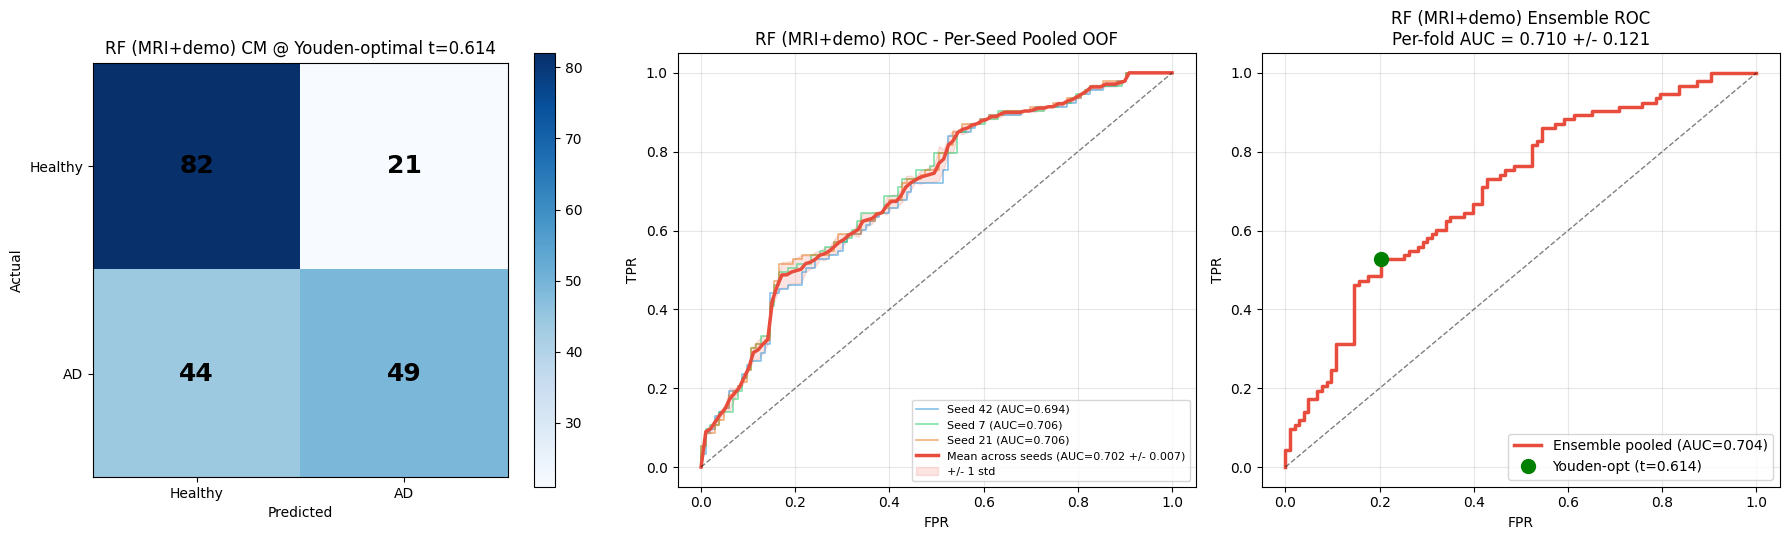

Saved plot: /content/drive/MyDrive/alzheimer_project/results_kfold_v3/random_forest_demo_plots.png


In [19]:
# %% ========================================================================
# Plot results for RF (MRI + demographics)
# ========================================================================
rf_report = print_full_results(rf_demo_results)
plot_architecture_results(rf_demo_results, rf_report,
                          save_path=str(RESULTS_DIR / 'random_forest_demo_plots.png'))

In [ ]:
# ============================================================================
#  MULTI-MODAL PRETRAINED ResNet-18 (MRI + Age + Sex)
#  Paste these as NEW cells at the end of the notebook
#  Each # %% block = one notebook cell
# ============================================================================


# %% ========================================================================
# CELL: ## 22. Multi-Modal: Inject Tabular Features into Cached Data
# ========================================================================
# Add Age (z-scored) and Sex (binary) to each cached subject.
# MONAI augmentation transforms only operate on keys=['image'],
# so the 'tabular' key passes through untouched.

from sklearn.preprocessing import LabelEncoder as _LE

_ages = df['Age'].values.astype(np.float32)
_age_mean, _age_std = _ages.mean(), _ages.std()
_ages_z = (_ages - _age_mean) / _age_std

_sexes = (_LE().fit_transform(df['M/F'].astype(str))).astype(np.float32)  # F=0, M=1

for i in range(len(full_ds)):
    full_ds[i]['tabular'] = torch.tensor([_ages_z[i], _sexes[i]], dtype=torch.float32)

print(f'Injected tabular features into {len(full_ds)} cached subjects')
print(f'  Age:  mean={_age_mean:.1f}, std={_age_std:.1f} → z-scored')
print(f'  Sex:  {int(_sexes.sum())} male / {int(len(_sexes)-_sexes.sum())} female')
print(f'  Shape per subject: {full_ds[0]["tabular"].shape}')  # torch.Size([2])


Injected tabular features into 196 cached subjects
  Age:  mean=75.6, std=8.7 → z-scored
  Sex:  66 male / 130 female
  Shape per subject: torch.Size([2])


In [ ]:


# %% ========================================================================
# CELL: ## 23. Multi-Modal Model Definition
# ========================================================================

class MultiModalResNet(nn.Module):
    """Pretrained ResNet-18 backbone fused with tabular features (Age, Sex)."""

    def __init__(self, backbone, n_tabular=2, n_classes=2, dropout=0.5):
        """
        Args:
            backbone: MONAI ResNet-18 with pretrained weights loaded.
                      Its .fc will be replaced with Identity.
            n_tabular: number of tabular features (default=2: age, sex).
        """
        super().__init__()
        self.backbone = backbone
        self.backbone.fc = nn.Identity()      # strip original head → returns 512-d

        self.tab_net = nn.Sequential(
            nn.Linear(n_tabular, 16),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512 + 16, n_classes),   # fused dimension
        )

    def forward(self, x_img, x_tab):
        img_feat = self.backbone(x_img)       # [B, 512]
        tab_feat = self.tab_net(x_tab)        # [B, 16]
        fused = torch.cat([img_feat, tab_feat], dim=1)  # [B, 528]
        return self.classifier(fused)


MM_LABEL = 'MultiModal-PT'

def build_multimodal(seed=RANDOM_SEED):
    """Build multi-modal ResNet-18 with MedicalNet pretrained backbone + tabular head."""
    seed_everything(seed)

    # 1. Fresh MONAI ResNet-18
    base = resnet18(spatial_dims=3, n_input_channels=1, num_classes=NUM_CLASSES)

    # 2. Load MedicalNet weights (same logic as build_resnet18_pretrained)
    ckpt = torch.load(PRETRAINED_WEIGHTS, map_location='cpu', weights_only=False)
    pt_dict = ckpt.get('state_dict', ckpt)
    pt_dict = {k.replace('module.', ''): v for k, v in pt_dict.items()}
    model_dict = base.state_dict()
    matched = {k: v for k, v in pt_dict.items()
               if k in model_dict and v.shape == model_dict[k].shape}
    model_dict.update(matched)
    base.load_state_dict(model_dict)
    print(f'  MedicalNet: loaded {len(matched)}/{len(model_dict)} layers')

    # 3. Wrap in multi-modal architecture
    model = MultiModalResNet(base, n_tabular=2, n_classes=NUM_CLASSES, dropout=PT_DROPOUT)
    return model.to(device)

# Quick verification
_test = build_multimodal(42)
_dummy_img = torch.randn(2, 1, *INPUT_SIZE).to(device)
_dummy_tab = torch.randn(2, 2).to(device)
_out = _test(_dummy_img, _dummy_tab)
print(f'Output shape: {_out.shape}')  # [2, 2]
del _test, _dummy_img, _dummy_tab, _out
torch.cuda.empty_cache()
print('Multi-modal model builder verified ✓')


  MedicalNet: loaded 102/125 layers
Output shape: torch.Size([2, 2])
Multi-modal model builder verified ✓


In [ ]:


# %% ========================================================================
# CELL: ## 24. Multi-Modal Training Engine
# ========================================================================

def mm_train_one_epoch(model, loader, criterion, optimizer):
    """Train multi-modal model for one epoch with gradient accumulation."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(loader):
        images  = batch['image'].to(device)
        tabular = batch['tabular'].to(device)
        labels  = batch['label'].to(device)
        outputs = model(images, tabular)
        loss = criterion(outputs, labels) / GRAD_ACCUM_STEPS
        loss.backward()
        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(loader):
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
        running_loss += loss.item() * GRAD_ACCUM_STEPS * images.size(0)
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()
    return running_loss / total, correct / total


@torch.no_grad()
def mm_evaluate(model, loader, criterion, tta=False):
    """Evaluate multi-modal model. TTA = flip along x-axis."""
    model.eval()
    running_loss = 0.0
    all_labels, all_probs = [], []
    for batch in loader:
        images  = batch['image'].to(device)
        tabular = batch['tabular'].to(device)
        labels  = batch['label'].to(device)
        out_orig = model(images, tabular)
        loss = criterion(out_orig, labels)
        running_loss += loss.item() * images.size(0)
        if tta:
            out_flip = model(torch.flip(images, dims=[2]), tabular)
            probs = (torch.softmax(out_orig.float(), 1) +
                     torch.softmax(out_flip.float(), 1)) / 2.0
        else:
            probs = torch.softmax(out_orig.float(), 1)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0
    return running_loss / len(all_labels), auc, all_labels, all_probs


def run_kfold_multimodal():
    """
    5-Fold CV × 3-Seed ensemble for multi-modal pretrained ResNet-18.
    Same two-phase strategy as pretrained-only:
      Phase 1: freeze backbone, train tab_net + classifier only.
      Phase 2: unfreeze layer3 + layer4 with discriminative LR.
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    save_dir = CHECKPOINT_DIR / 'multimodal_pt'
    save_dir.mkdir(exist_ok=True)

    n = len(all_data)
    all_test_probs  = np.zeros(n)
    all_test_labels = np.zeros(n, dtype=int)
    per_seed_probs  = {s: np.zeros(n) for s in ENSEMBLE_SEEDS}
    fold_records    = []

    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(np.zeros(n), all_labels)):
        print(f'\n{"="*70}\n  FOLD {fold_idx+1}/{N_FOLDS}\n{"="*70}')

        # Train / val split (same as CNN folds)
        trainval_lbls = all_labels[trainval_idx]
        sub_train, sub_val = train_test_split(
            np.arange(len(trainval_idx)), test_size=VAL_FRACTION,
            stratify=trainval_lbls, random_state=RANDOM_SEED,
        )
        train_idx = trainval_idx[sub_train]
        val_idx   = trainval_idx[sub_val]
        print(f'  Split: {len(train_idx)} train, {len(val_idx)} val, {len(test_idx)} test')

        # Class weights
        cls_counts = np.bincount(all_labels[train_idx]).astype(np.float32)
        cls_w = 1.0 / cls_counts
        cls_w = cls_w / cls_w.sum() * len(cls_counts)
        weights_tensor = torch.FloatTensor(cls_w).to(device)

        # Datasets & loaders
        train_ds = AugmentedSubset(full_ds, train_idx, aug=train_aug)
        val_ds   = AugmentedSubset(full_ds, val_idx,   aug=None)
        test_ds  = AugmentedSubset(full_ds, test_idx,  aug=None)
        val_loader  = make_loader(val_ds,  shuffle=False)
        test_loader = make_loader(test_ds, shuffle=False)

        fold_seed_probs  = []
        fold_test_labels = None
        per_seed_aucs    = {}

        for seed in ENSEMBLE_SEEDS:
            seed_everything(seed)
            model = build_multimodal(seed)
            criterion = nn.CrossEntropyLoss(weight=weights_tensor,
                                            label_smoothing=LABEL_SMOOTHING)
            train_loader = make_loader(train_ds, shuffle=True, seed=seed)

            # ====== PHASE 1: Head only ======
            for name, param in model.backbone.named_parameters():
                param.requires_grad = False
            # tab_net + classifier are trainable
            opt_p1 = torch.optim.Adam(
                list(model.tab_net.parameters()) + list(model.classifier.parameters()),
                lr=PT_LR_HEAD, weight_decay=WEIGHT_DECAY,
            )
            t_seed = time.time()
            for ep in range(1, PT_PHASE1_EPOCHS + 1):
                mm_train_one_epoch(model, train_loader, criterion, opt_p1)

            val_loss_p1, val_auc_p1, _, _ = mm_evaluate(model, val_loader, criterion, tta=False)
            print(f'    Seed {seed:>3d} Phase1 done ({PT_PHASE1_EPOCHS}ep): '
                  f'val_auc={val_auc_p1:.3f}, val_loss={val_loss_p1:.3f}')

            # ====== PHASE 2: Unfreeze layer3 + layer4 ======
            for name, param in model.backbone.named_parameters():
                if any(x in name for x in ['layer3', 'layer4']):
                    param.requires_grad = True

            opt_p2 = torch.optim.Adam([
                {'params': [p for n, p in model.backbone.named_parameters()
                            if 'layer3' in n and p.requires_grad],
                 'lr': PT_LR_DEEP},
                {'params': [p for n, p in model.backbone.named_parameters()
                            if 'layer4' in n and p.requires_grad],
                 'lr': PT_LR_DEEPER},
                {'params': model.tab_net.parameters(),    'lr': PT_LR_HEAD_P2},
                {'params': model.classifier.parameters(), 'lr': PT_LR_HEAD_P2},
            ], weight_decay=WEIGHT_DECAY)

            sched_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
                opt_p2, T_max=PT_PHASE2_EPOCHS, eta_min=1e-7,
            )

            best_score    = -float('inf')
            best_val_auc  = 0.0
            best_val_loss = float('inf')
            best_state    = None
            best_epoch    = 0
            patience_counter = 0

            for ep in range(1, PT_PHASE2_EPOCHS + 1):
                mm_train_one_epoch(model, train_loader, criterion, opt_p2)
                val_loss, val_auc, _, _ = mm_evaluate(model, val_loader, criterion, tta=False)
                sched_p2.step()

                score = val_auc - COMPOSITE_LOSS_WEIGHT * val_loss
                if ep >= PT_WARMUP_BEST:
                    if score > best_score:
                        best_score    = score
                        best_val_auc  = val_auc
                        best_val_loss = val_loss
                        best_state = {k: v.detach().cpu().clone()
                                      for k, v in model.state_dict().items()}
                        best_epoch = PT_PHASE1_EPOCHS + ep
                        patience_counter = 0
                    else:
                        patience_counter += 1

                if ep >= PT_MIN_EPOCHS_P2 and patience_counter >= PT_PATIENCE:
                    break

            total_ep = PT_PHASE1_EPOCHS + ep

            # Load best checkpoint
            if best_state is not None:
                model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

            torch.save(model.state_dict(), save_dir / f'fold{fold_idx+1}_seed{seed}.pth')

            # Test with TTA
            _, _, t_lbls, t_probs = mm_evaluate(model, test_loader, criterion, tta=USE_TTA)
            fold_seed_probs.append(t_probs)
            fold_test_labels = t_lbls
            per_seed_probs[seed][test_idx] = t_probs

            seed_test_auc = roc_auc_score(t_lbls, t_probs)
            per_seed_aucs[seed] = seed_test_auc
            print(f'    Seed {seed:>3d}: best ep {best_epoch:>2d} (stopped {total_ep:>2d}), '
                  f'score={best_score:+.3f} (val_auc={best_val_auc:.3f}, '
                  f'val_loss={best_val_loss:.3f}), '
                  f'test_auc={seed_test_auc:.3f}, time={(time.time()-t_seed)/60:.1f}m')

            del model, opt_p1, opt_p2, sched_p2, best_state
            torch.cuda.empty_cache()

        # Ensemble across seeds
        fold_ens_probs = np.mean(np.stack(fold_seed_probs), axis=0)
        all_test_probs[test_idx]  = fold_ens_probs
        all_test_labels[test_idx] = fold_test_labels
        ens_auc = roc_auc_score(fold_test_labels, fold_ens_probs)

        fold_records.append({
            'fold': fold_idx + 1,
            'test_idx': test_idx.tolist(),
            'ensemble_auc': ens_auc,
            'per_seed_aucs': per_seed_aucs,
        })
        print(f'  Fold {fold_idx+1} ensemble (TTA={USE_TTA}): AUC={ens_auc:.3f}')

        # Incremental save
        np.savez(
            RESULTS_DIR / 'multimodal_pt_progress.npz',
            probs=all_test_probs, labels=all_test_labels,
            completed_folds=fold_idx + 1,
            **{f'per_seed_{s_}': per_seed_probs[s_] for s_ in ENSEMBLE_SEEDS},
        )

    results = {
        'model_name': MM_LABEL,
        'all_test_probs':  all_test_probs,
        'all_test_labels': all_test_labels,
        'per_seed_probs':  per_seed_probs,
        'fold_records':    fold_records,
        'weight_dir':      str(save_dir),
    }

    np.savez(
        RESULTS_DIR / 'multimodal_pt_results.npz',
        probs=all_test_probs, labels=all_test_labels,
        **{f'per_seed_{s}': per_seed_probs[s] for s in ENSEMBLE_SEEDS},
    )
    print(f'\nSaved multimodal_pt_results.npz to {RESULTS_DIR}')
    return results

print('Multi-modal training engine ready')
print(f'  Will train {N_FOLDS} folds × {len(ENSEMBLE_SEEDS)} seeds = '
      f'{N_FOLDS * len(ENSEMBLE_SEEDS)} models')


Multi-modal training engine ready
  Will train 5 folds × 3 seeds = 15 models


In [ ]:


# %% ========================================================================
# CELL: ## 25. Train Multi-Modal Pretrained ResNet-18
# ========================================================================
print(f'Starting Multi-Modal Pretrained ResNet-18: '
      f'{N_FOLDS} folds × {len(ENSEMBLE_SEEDS)} seeds')
t0 = time.time()
mm_results = run_kfold_multimodal()
print(f'\nMulti-Modal done in {(time.time()-t0)/3600:.2f} h')

Starting Multi-Modal Pretrained ResNet-18: 5 folds × 3 seeds

  FOLD 1/5
  Split: 117 train, 39 val, 40 test
  MedicalNet: loaded 102/125 layers
    Seed  42 Phase1 done (10ep): val_auc=0.606, val_loss=0.716
    Seed  42: best ep 15 (stopped 27), score=+0.469 (val_auc=0.667, val_loss=0.660), test_auc=0.509, time=8.1m
  MedicalNet: loaded 102/125 layers
    Seed   7 Phase1 done (10ep): val_auc=0.614, val_loss=0.681
    Seed   7: best ep 16 (stopped 28), score=+0.510 (val_auc=0.704, val_loss=0.646), test_auc=0.571, time=8.2m
  MedicalNet: loaded 102/125 layers
    Seed  21 Phase1 done (10ep): val_auc=0.619, val_loss=0.687
    Seed  21: best ep 18 (stopped 30), score=+0.489 (val_auc=0.688, val_loss=0.664), test_auc=0.494, time=8.8m
  Fold 1 ensemble (TTA=True): AUC=0.521

  FOLD 2/5
  Split: 117 train, 40 val, 39 test
  MedicalNet: loaded 102/125 layers
    Seed  42 Phase1 done (10ep): val_auc=0.516, val_loss=0.783
    Seed  42: best ep 28 (stopped 40), score=+0.477 (val_auc=0.689, val_lo


  MultiModal-PT - 5-FOLD CV x 3-SEED ENSEMBLE (TTA=True)
  196 subjects (each tested exactly once)

  *** PRIMARY METRICS - per-fold mean +/- std (k-fold standard) ***
  *** All metrics @ Youden-optimal threshold = 0.522 (J=0.322) ***
    AUC          = 0.684 +/- 0.105
    Accuracy     = 0.659 +/- 0.078
    Sensitivity  = 0.722 +/- 0.182
    Specificity  = 0.601 +/- 0.165
    F1 (weighted)= 0.650 +/- 0.085

  Per-fold breakdown:


,fold,AUC,Accuracy,Sensitivity,Specificity,F1
0,1,0.521,0.550,0.421,0.667,0.543
1,2,0.685,0.718,0.722,0.714,0.718
2,3,0.714,0.667,0.833,0.524,0.660
3,4,0.687,0.615,0.895,0.350,0.586
4,5,0.813,0.744,0.737,0.750,0.744
5,mean,0.684,0.659,0.722,0.601,0.650
6,std,0.105,0.078,0.182,0.165,0.085



  --- Pooled OOF (concatenated 196 predictions, secondary) ---
    @ Youden t=0.522: AUC=0.672, Acc=0.658, Sens=0.720, Spec=0.602
    @ default  t=0.50: AUC=0.672, Acc=0.633, Sens=0.731, Spec=0.544

  Confusion Matrix @ Youden threshold 0.522 (pooled OOF):
                   Predicted
                   Healthy   AD
   Actual Healthy     62      41
   Actual AD          26      67

  Classification report @ Youden threshold 0.522:
              precision    recall  f1-score   support

     Healthy       0.70      0.60      0.65       103
          AD       0.62      0.72      0.67        93

    accuracy                           0.66       196
   macro avg       0.66      0.66      0.66       196
weighted avg       0.66      0.66      0.66       196

  Threshold comparison (pooled OOF):


,threshold,accuracy,sensitivity,specificity,f1
0,0.35,0.587,0.892,0.311,0.551
1,0.40,0.622,0.860,0.408,0.604
2,0.45,0.612,0.796,0.447,0.601
3,0.50,0.633,0.731,0.544,0.630
4,0.55,0.648,0.634,0.660,0.648
5,0.60,0.648,0.505,0.777,0.641


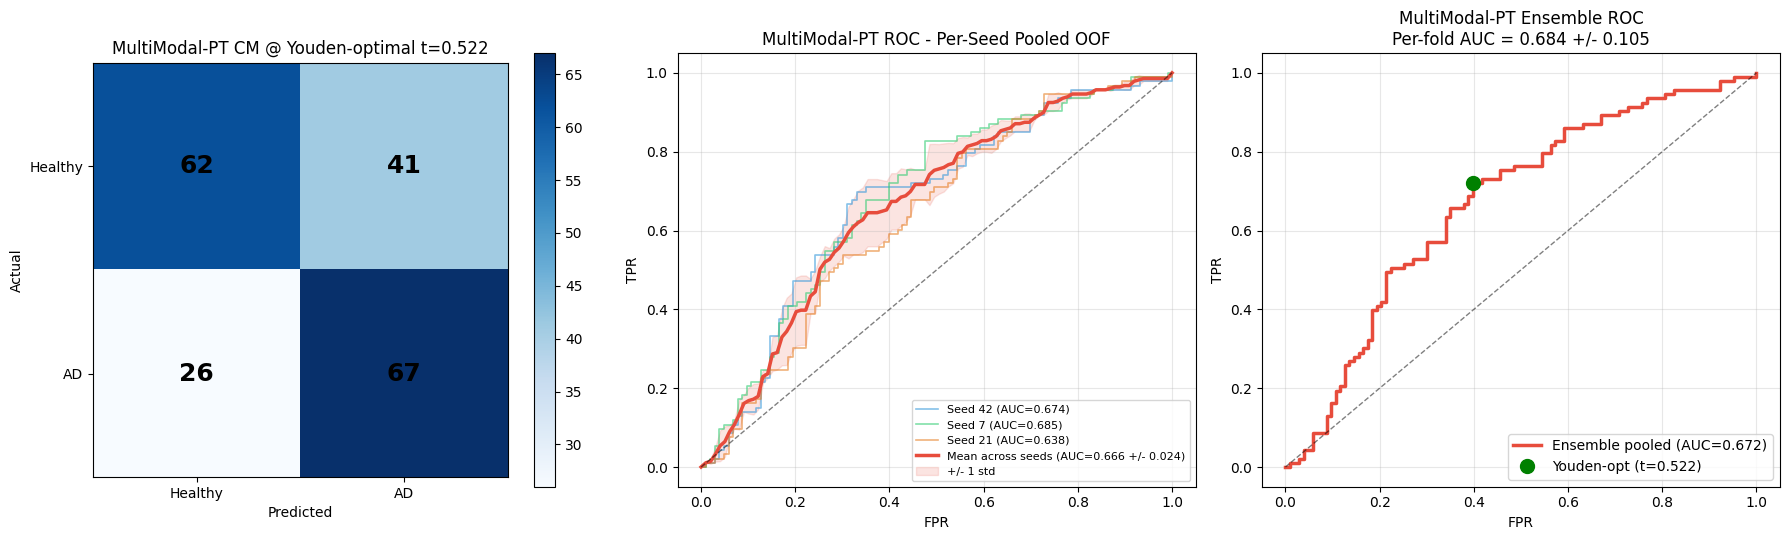

Saved plot: /content/drive/MyDrive/alzheimer_project/results_kfold_v3/multimodal_pt_plots.png


In [22]:


# %% ========================================================================
# CELL: ## 26. Multi-Modal: Results & Plots
# ========================================================================
mm_report = print_full_results(mm_results)
plot_architecture_results(mm_results, mm_report,
                          save_path=str(RESULTS_DIR / 'multimodal_pt_plots.png'))


In [ ]:


# %% ========================================================================
# CELL: ## 27. Multi-Modal: Threshold Sweep
# ========================================================================
print('Multi-Modal Pretrained — Threshold Sweep')
print('-' * 60)
mm_sweep = []
for t in [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    s = summarize_predictions(mm_results['all_test_labels'],
                              mm_results['all_test_probs'], t)
    mm_sweep.append({
        'threshold': t,
        'accuracy':    f'{s["accuracy"]:.3f}',
        'sensitivity': f'{s["sensitivity"]:.3f}',
        'specificity': f'{s["specificity"]:.3f}',
        'f1':          f'{s["f1"]:.3f}',
    })
display(pd.DataFrame(mm_sweep))


Multi-Modal Pretrained — Threshold Sweep
------------------------------------------------------------


,threshold,accuracy,sensitivity,specificity,f1
0,0.35,0.587,0.892,0.311,0.551
1,0.40,0.622,0.860,0.408,0.604
2,0.45,0.612,0.796,0.447,0.601
3,0.50,0.633,0.731,0.544,0.630
4,0.55,0.648,0.634,0.660,0.648
5,0.60,0.648,0.505,0.777,0.641


In [21]:
# Reload multi-modal results after disconnect
mm_results = reload_results('MultiModal-PT', 'multimodal_pt_results.npz')
mm_report  = print_full_results(mm_results)
print('Multi-modal results reloaded ✓')


  MultiModal-PT - 5-FOLD CV x 3-SEED ENSEMBLE (TTA=True)
  196 subjects (each tested exactly once)

  *** PRIMARY METRICS - per-fold mean +/- std (k-fold standard) ***
  *** All metrics @ Youden-optimal threshold = 0.522 (J=0.322) ***
    AUC          = 0.684 +/- 0.105
    Accuracy     = 0.659 +/- 0.078
    Sensitivity  = 0.722 +/- 0.182
    Specificity  = 0.601 +/- 0.165
    F1 (weighted)= 0.650 +/- 0.085

  Per-fold breakdown:


,fold,AUC,Accuracy,Sensitivity,Specificity,F1
0,1,0.521,0.550,0.421,0.667,0.543
1,2,0.685,0.718,0.722,0.714,0.718
2,3,0.714,0.667,0.833,0.524,0.660
3,4,0.687,0.615,0.895,0.350,0.586
4,5,0.813,0.744,0.737,0.750,0.744
5,mean,0.684,0.659,0.722,0.601,0.650
6,std,0.105,0.078,0.182,0.165,0.085



  --- Pooled OOF (concatenated 196 predictions, secondary) ---
    @ Youden t=0.522: AUC=0.672, Acc=0.658, Sens=0.720, Spec=0.602
    @ default  t=0.50: AUC=0.672, Acc=0.633, Sens=0.731, Spec=0.544

  Confusion Matrix @ Youden threshold 0.522 (pooled OOF):
                   Predicted
                   Healthy   AD
   Actual Healthy     62      41
   Actual AD          26      67

  Classification report @ Youden threshold 0.522:
              precision    recall  f1-score   support

     Healthy       0.70      0.60      0.65       103
          AD       0.62      0.72      0.67        93

    accuracy                           0.66       196
   macro avg       0.66      0.66      0.66       196
weighted avg       0.66      0.66      0.66       196

  Threshold comparison (pooled OOF):


,threshold,accuracy,sensitivity,specificity,f1
0,0.35,0.587,0.892,0.311,0.551
1,0.40,0.622,0.860,0.408,0.604
2,0.45,0.612,0.796,0.447,0.601
3,0.50,0.633,0.731,0.544,0.630
4,0.55,0.648,0.634,0.660,0.648
5,0.60,0.648,0.505,0.777,0.641


Multi-modal results reloaded ✓


  ALL MODELS COMPARISON @ t=0.5
  5-Fold CV, 196 subjects


,Model,AUC,Accuracy,Sensitivity,Specificity,F1
0,ResNet-18 (scratch),0.681,0.592,0.667,0.524,0.590
1,DenseNet-121,0.663,0.628,0.581,0.670,0.627
2,Pretrained ResNet-18,0.674,0.628,0.753,0.515,0.623
3,Multi-Modal (MRI+Age+Sex),0.672,0.633,0.731,0.544,0.630
4,RF (MRI+demographics),0.704,0.628,0.634,0.621,0.628


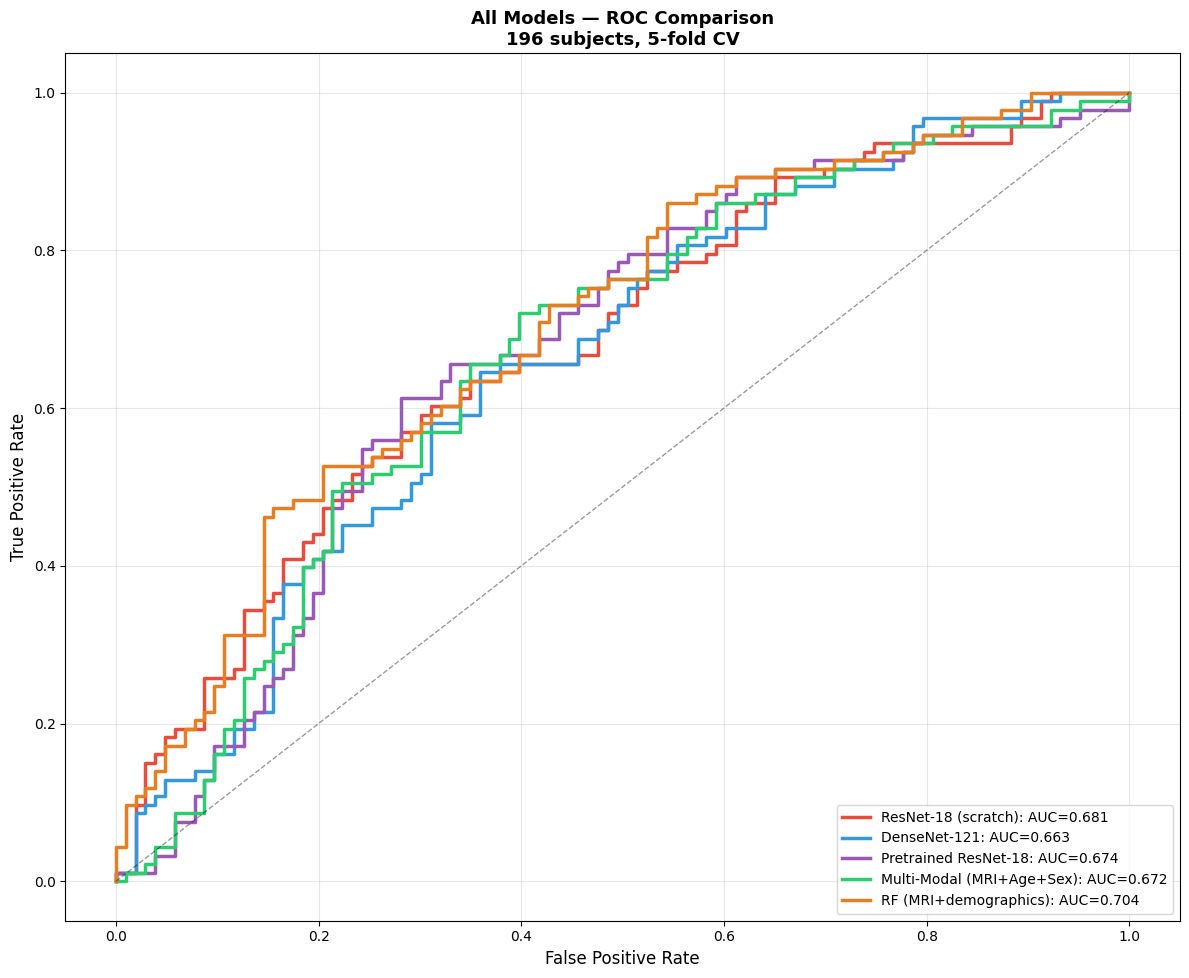


Saved: all_models_roc.png and all_models_comparison.csv

  KEY FINDING
  All models achieve AUC in the 0.66–0.72 range.
  The primary bottleneck is dataset size (n=196),
  not architecture, pretraining, or feature fusion.


In [26]:


# %% ========================================================================
# CELL: ## 28. Final Comparison — All Models @ t=0.50
# ========================================================================

# Reload pretrained results if needed
try:
    _ = resnet_pt_results['model_name']
except NameError:
    resnet_pt_results = reload_results('ResNet-18-PT', 'resnet18_pt_results.npz')

all_models = [
    (resnet_results,      'ResNet-18 (scratch)',   '#e74c3c', '-'),
    (densenet_results,    'DenseNet-121',          '#3498db', '-'),
    (resnet_pt_results,   'Pretrained ResNet-18',  '#9b59b6', '-'),
    (mm_results,          'Multi-Modal (MRI+Age+Sex)', '#2ecc71', '-'),
    (rf_demo_results,     'RF (MRI+demographics)', '#e67e22', '-'),
]

# ---- Table ----
COMP_THRESHOLD = 0.50
comp_rows = []
for r, label, *_ in all_models:
    s = summarize_predictions(r['all_test_labels'], r['all_test_probs'], COMP_THRESHOLD)
    comp_rows.append({
        'Model':       label,
        'AUC':         f'{s["auc"]:.3f}',
        'Accuracy':    f'{s["accuracy"]:.3f}',
        'Sensitivity': f'{s["sensitivity"]:.3f}',
        'Specificity': f'{s["specificity"]:.3f}',
        'F1':          f'{s["f1"]:.3f}',
    })

comp_df = pd.DataFrame(comp_rows)
print('=' * 80)
print(f'  ALL MODELS COMPARISON @ t={COMP_THRESHOLD}')
print(f'  {N_FOLDS}-Fold CV, {len(all_labels)} subjects')
print('=' * 80)
display(comp_df)

# ---- ROC ----
fig, ax = plt.subplots(1, 1, figsize=(12, 9.88))
for r, label, color, ls in all_models:
    fpr, tpr, _ = roc_curve(r['all_test_labels'], r['all_test_probs'])
    auc_val = roc_auc_score(r['all_test_labels'], r['all_test_probs'])
    ax.plot(fpr, tpr, color=color, lw=2.5, ls=ls,
            label=f'{label}: AUC={auc_val:.3f}')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'All Models — ROC Comparison\n'
             f'{len(all_labels)} subjects, {N_FOLDS}-fold CV',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'all_models_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

comp_df.to_csv(RESULTS_DIR / 'all_models_comparison.csv', index=False)
print(f'\nSaved: all_models_roc.png and all_models_comparison.csv')

print('\n' + '=' * 80)
print('  KEY FINDING')
print('=' * 80)
print('  All models achieve AUC in the 0.66–0.72 range.')
print('  The primary bottleneck is dataset size (n=196),')
print('  not architecture, pretraining, or feature fusion.')
print('=' * 80)



